# The Middle Income Trap
### What Separates Countries That Break Through From Those That Stall?

---

## Introduction

**Target Audience:** Policymakers and international development researchers working in middle-income economies.

**Motivation:** The "middle income trap" is one of the central questions in development economics. Countries like Brazil, South Africa, Mexico, and Thailand reached middle-income status through cheap labor and export-led growth, but have stalled for decades. Meanwhile, South Korea, Poland, and Chile broke through to high-income status. Understanding what separates these two groups has direct policy implications.

**Approach:** We use the World Bank API to pull 15 macroeconomic indicators for 7 countries (1980–2023), supplemented by two external datasets on governance quality and innovation/R&D. We compare a **Success group** (Korea, Poland, Chile) against a **Trapped group** (Brazil, South Africa, Mexico, Thailand) through EDA, feature engineering, SQL analysis, and predictive modeling.

**Key Questions:**
1. When did the "success" countries begin to pull away from the "trapped" ones?
2. Which indicators show the largest differences between groups?
3. Do education and sustained industrialization predict successful transition?
4. Are there structural patterns (governance, export orientation) that separate the groups?
5. Can we build predictive models that reliably classify the two groups?

---
## 1. Setup and Imports

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

---
## 2. Data Collection via World Bank API

We use the World Bank Indicators API (v2). The API returns paginated JSON, so we use a `while` loop to retrieve **all** pages for each indicator. We then use `pd.json_normalize()` to convert the JSON into DataFrames.

In [2]:
COUNTRIES_STR = 'KOR;POL;CHL;BRA;ZAF;MEX;THA'

SUCCESS_LIST = ['Korea, Rep.', 'Poland', 'Chile']
TRAPPED_LIST = ['Brazil', 'South Africa', 'Mexico', 'Thailand']

INDICATORS = {
    'NY.GDP.PCAP.CD':      'gdp_per_capita',
    'NY.GDP.PCAP.KD':      'gdp_per_capita_const',
    'NY.GDP.MKTP.KD.ZG':   'gdp_growth',
    'NV.IND.TOTL.ZS':      'industry_pct_gdp',
    'NV.IND.MANF.ZS':      'manufacturing_pct_gdp',
    'NV.SRV.TOTL.ZS':      'services_pct_gdp',
    'SE.XPD.TOTL.GD.ZS':   'education_expenditure',
    'SE.TER.ENRR':         'tertiary_enrollment',
    'NE.EXP.GNFS.ZS':     'exports_pct_gdp',
    'FP.CPI.TOTL.ZG':     'inflation_rate',
    'SL.UEM.TOTL.ZS':     'unemployment_rate',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_pct_gdp',
    'GC.DOD.TOTL.GD.ZS':  'govt_debt_pct_gdp',
    'NY.GNS.ICTR.ZS':     'gross_savings_pct_gni',
    'SP.POP.GROW':         'population_growth'
}

START_YEAR = 1980
END_YEAR = 2023

print(f"Indicators to download: {len(INDICATORS)}")
print(f"Time range: {START_YEAR} to {END_YEAR}")

Indicators to download: 15
Time range: 1980 to 2023


In [3]:
def fetch_wb_indicator(indicator_code, countries, start_year, end_year):
    """
    Fetch ALL pages of data from the World Bank API for a given indicator.
    Uses a while loop to handle pagination.
    Returns a list of raw JSON records.
    """
    url = f'https://api.worldbank.org/v2/country/{countries}/indicator/{indicator_code}'
    all_records = []
    page = 1
    total_pages = 1

    while page <= total_pages:
        params = {
            'format': 'json',
            'date': f'{start_year}:{end_year}',
            'per_page': 500,
            'page': page
        }
        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"  ERROR: {indicator_code} returned status {response.status_code}")
            break

        data = response.json()

        if len(data) < 2 or data[1] is None:
            print(f"  WARNING: No data for {indicator_code}")
            break

        total_pages = data[0]['pages']
        all_records.extend(data[1])
        page += 1

    print(f"  {indicator_code:<30s} -> {len(all_records):>4d} records")
    return all_records

In [4]:
print("Downloading from World Bank API...")
print("=" * 55)

indicator_dfs = {}  

for ind_code, col_name in INDICATORS.items():
    records = fetch_wb_indicator(ind_code, COUNTRIES_STR, START_YEAR, END_YEAR)

    if not records:
        print(f"  Skipping {ind_code} (no records)")
        continue

    df_raw = pd.json_normalize(records)

    df_clean = df_raw[['country.value', 'date', 'value']].copy()
    df_clean.columns = ['country', 'year', col_name]
    df_clean['year'] = df_clean['year'].astype(int)
    df_clean = df_clean.sort_values(['country', 'year']).reset_index(drop=True)

    indicator_dfs[col_name] = df_clean

print("=" * 55)
print(f"\nSuccessfully downloaded {len(indicator_dfs)} indicators.")

  NY.GDP.PCAP.CD                 ->  308 records
  NY.GDP.PCAP.KD                 ->  308 records
  NY.GDP.MKTP.KD.ZG              ->  308 records
  NV.IND.TOTL.ZS                 ->  308 records
  NV.IND.MANF.ZS                 ->  308 records
  NV.SRV.TOTL.ZS                 ->  308 records
  SE.XPD.TOTL.GD.ZS              ->  308 records
  SE.TER.ENRR                    ->  308 records
  NE.EXP.GNFS.ZS                 ->  308 records
  FP.CPI.TOTL.ZG                 ->  308 records
  SL.UEM.TOTL.ZS                 ->  308 records
  BX.KLT.DINV.WD.GD.ZS           ->  308 records
  GC.DOD.TOTL.GD.ZS              ->  308 records
  NY.GNS.ICTR.ZS                 ->  308 records
  SP.POP.GROW                    ->  308 records

Successfully downloaded 15 indicators.


In [5]:
indicator_names = list(indicator_dfs.keys())

df = indicator_dfs[indicator_names[0]]

for name in indicator_names[1:]:
    df = df.merge(indicator_dfs[name], on=['country', 'year'], how='outer')

df = df.sort_values(['country', 'year']).reset_index(drop=True)

df['group'] = df['country'].apply(
    lambda c: 'Success' if c in SUCCESS_LIST else 'Trapped'
)

print(f"Final dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nCountries: {sorted(df['country'].unique())}")
print(f"\nGroup breakdown:")
print(df.groupby('group')['country'].nunique())
df.head(10)

Final dataset: 308 rows x 18 columns

Countries: ['Brazil', 'Chile', 'Korea, Rep.', 'Mexico', 'Poland', 'South Africa', 'Thailand']

Group breakdown:
group
Success    3
Trapped    4
Name: country, dtype: int64


,country,year,gdp_per_capita,gdp_per_capita_const,gdp_growth,industry_pct_gdp,manufacturing_pct_gdp,services_pct_gdp,education_expenditure,tertiary_enrollment,exports_pct_gdp,inflation_rate,unemployment_rate,fdi_pct_gdp,govt_debt_pct_gdp,gross_savings_pct_gni,population_growth,group
0,Brazil,1980,1958.571592,6472.851401,9.20,43.972540,21.986270,43.972540,NaN,NaN,8.962395,NaN,NaN,0.804993,NaN,17.689579,2.359691,Trapped
1,Brazil,1981,2079.709084,6055.097118,-4.25,45.803202,34.352402,45.803202,NaN,NaN,9.622840,101.725073,NaN,0.976687,NaN,19.039804,2.328675,Trapped
2,Brazil,1982,2137.625036,5967.778309,0.83,45.192431,33.894323,45.192431,NaN,NaN,7.900485,100.543359,NaN,1.072558,NaN,15.877807,2.279144,Trapped
3,Brazil,1983,1461.255827,5664.963033,-2.93,42.738428,32.682328,42.738428,NaN,NaN,12.243756,135.027682,NaN,0.848376,NaN,14.275817,2.233653,Trapped
4,Brazil,1984,1419.731546,5841.749193,5.40,46.638839,33.991019,43.476884,NaN,NaN,15.035413,192.121733,NaN,0.846342,NaN,17.488679,2.186255,Trapped
5,Brazil,1985,1556.129718,6167.512727,7.85,43.530007,32.384643,41.427108,NaN,NaN,12.948579,225.989665,NaN,0.683328,NaN,20.183632,2.130583,Trapped
6,Brazil,1986,1854.037752,6494.280132,7.49,42.004142,30.698354,40.669431,NaN,NaN,9.217279,147.142826,NaN,0.134513,NaN,17.901516,2.060146,Trapped
7,Brazil,1987,2006.002262,6591.608070,3.53,42.894585,29.892473,41.235268,NaN,NaN,9.828482,228.336163,NaN,0.412991,NaN,22.660603,1.981571,Trapped
8,Brazil,1988,2140.650276,6463.004709,-0.06,42.269731,29.977229,44.782018,NaN,NaN,11.667359,629.114509,NaN,0.910739,NaN,25.653684,1.910282,Trapped
9,Brazil,1989,2818.992780,6545.425003,3.16,42.283831,29.260896,48.367309,NaN,NaN,8.929610,1430.723725,NaN,0.273856,NaN,35.808556,1.843900,Trapped


---
## 3. Data Quality Checks

In [6]:
print("=== Dataset Overview ===")
print(f"Shape      : {df.shape}")
print(f"Countries  : {df['country'].nunique()} -> {sorted(df['country'].unique())}")
print(f"Year range : {df['year'].min()} to {df['year'].max()}")
print(f"\nData types:")
print(df.dtypes)

print(f'\n=== Categorical Variable Checks ===')
print(f'\nCountry distribution (rows per country):')
print(df['country'].value_counts().sort_index())
print(f'\nGroup distribution (rows per group):')
print(df['group'].value_counts())


=== Dataset Overview ===
Shape      : (308, 18)
Countries  : 7 -> ['Brazil', 'Chile', 'Korea, Rep.', 'Mexico', 'Poland', 'South Africa', 'Thailand']
Year range : 1980 to 2023

Data types:
country                   object
year                       int64
gdp_per_capita           float64
gdp_per_capita_const     float64
gdp_growth               float64
industry_pct_gdp         float64
manufacturing_pct_gdp    float64
services_pct_gdp         float64
education_expenditure    float64
tertiary_enrollment      float64
exports_pct_gdp          float64
inflation_rate           float64
unemployment_rate        float64
fdi_pct_gdp              float64
govt_debt_pct_gdp        float64
gross_savings_pct_gni    float64
population_growth        float64
group                     object
dtype: object

=== Categorical Variable Checks ===

Country distribution (rows per country):
country
Brazil          44
Chile           44
Korea, Rep.     44
Mexico          44
Poland          44
South Africa    44
Tha

=== Missing Values ===
                       count   pct
govt_debt_pct_gdp        198  64.3
tertiary_enrollment      160  51.9
education_expenditure     91  29.5
unemployment_rate         77  25.0
services_pct_gdp          28   9.1
industry_pct_gdp          15   4.9
manufacturing_pct_gdp     15   4.9
exports_pct_gdp           15   4.9
gross_savings_pct_gni     15   4.9
gdp_growth                11   3.6
gdp_per_capita            10   3.2
gdp_per_capita_const      10   3.2
fdi_pct_gdp               10   3.2
inflation_rate             1   0.3
population_growth          0   0.0


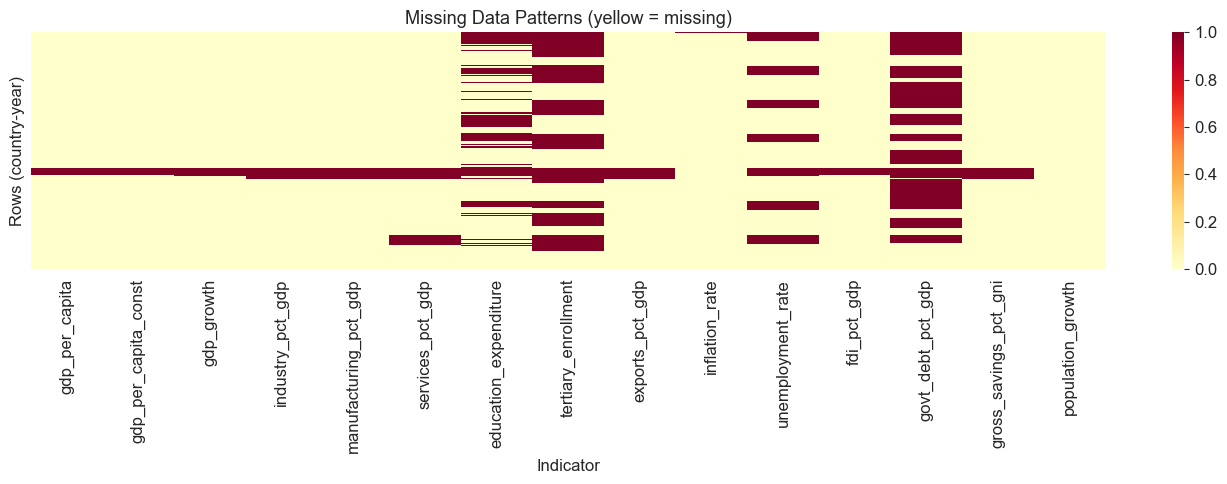


Govt debt and tertiary enrollment have the most gaps (concentrated in early decades).
Education expenditure and unemployment are also partially missing.


In [7]:
indicator_cols = list(INDICATORS.values())

indicator_cols = [c for c in indicator_cols if c in df.columns]

missing_pct = (df[indicator_cols].isnull().mean() * 100).round(1)
missing_count = df[indicator_cols].isnull().sum()

missing_df = pd.DataFrame({'count': missing_count, 'pct': missing_pct})
missing_df = missing_df.sort_values('pct', ascending=False)

print("=== Missing Values ===")
print(missing_df)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df[indicator_cols].isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
ax.set_title('Missing Data Patterns (yellow = missing)', fontsize=13)
ax.set_xlabel('Indicator')
ax.set_ylabel('Rows (country-year)')
plt.tight_layout()
plt.show()
print("\nGovt debt and tertiary enrollment have the most gaps (concentrated in early decades).")
print("Education expenditure and unemployment are also partially missing.")

In [8]:
print("=== Descriptive Statistics ===")
df[indicator_cols].describe().round(2)

=== Descriptive Statistics ===


,gdp_per_capita,gdp_per_capita_const,gdp_growth,industry_pct_gdp,manufacturing_pct_gdp,services_pct_gdp,education_expenditure,tertiary_enrollment,exports_pct_gdp,inflation_rate,unemployment_rate,fdi_pct_gdp,govt_debt_pct_gdp,gross_savings_pct_gni,population_growth
count,298.00,298.00,297.00,293.00,293.00,280.00,217.00,148.00,293.00,307.00,231.00,298.00,110.00,293.00,308.00
mean,7848.72,9120.61,3.57,31.78,20.06,55.66,4.37,55.94,30.73,50.14,8.79,2.32,37.82,22.88,1.12
std,7123.40,6431.03,3.84,5.48,6.06,5.29,0.98,26.85,14.99,256.78,7.74,2.08,22.53,7.43,0.77
min,708.73,1482.09,-11.50,18.19,8.53,40.67,2.25,10.52,6.73,-1.61,0.25,-0.86,3.67,2.92,-1.43
25%,2849.35,5318.42,1.58,28.51,15.44,52.61,3.58,38.85,21.85,3.24,3.24,0.75,20.26,17.34,0.65
50%,5733.74,7515.04,3.55,32.52,19.82,56.35,4.50,49.97,27.87,5.40,6.76,1.94,35.93,21.09,1.02
75%,10363.77,9979.36,5.84,35.54,25.50,59.13,5.00,75.42,37.66,13.22,10.95,3.29,49.88,27.97,1.57
max,37518.46,36347.70,13.47,46.64,34.35,73.34,6.56,106.71,71.42,2947.73,34.01,11.91,98.71,41.89,3.49


In [9]:
gdp_check = (
    df.groupby('country')['gdp_per_capita']
    .agg(['min', 'max', 'mean'])
    .round(0)
    .sort_values('max', ascending=False)
)
print("=== GDP Per Capita Sanity Check (current US$) ===")
print(gdp_check)
print("\nKorea's max should be >30,000. Brazil/Mexico/SA should peak ~10,000-15,000.")

=== GDP Per Capita Sanity Check (current US$) ===
                 min      max     mean
country                               
Korea, Rep.   1746.0  37518.0  17149.0
Poland        1731.0  22145.0   9638.0
Chile         1447.0  17067.0   7766.0
Mexico        1757.0  13861.0   7021.0
Brazil        1420.0  13397.0   5709.0
South Africa  1839.0   8646.0   4667.0
Thailand       709.0   7606.0   3399.0

Korea's max should be >30,000. Brazil/Mexico/SA should peak ~10,000-15,000.


In [10]:
dup_count = df.duplicated(subset=['country', 'year']).sum()
negative_gdp = (df['gdp_per_capita'] < 0).sum()

print(f"Duplicate (country, year) pairs : {dup_count}")
print(f"Negative GDP per capita values  : {negative_gdp}")

print(f"\n=== Year Coverage ===")
print(df.groupby('country')['year'].agg(['min', 'max', 'count']))

Duplicate (country, year) pairs : 0
Negative GDP per capita values  : 0

=== Year Coverage ===
               min   max  count
country                        
Brazil        1980  2023     44
Chile         1980  2023     44
Korea, Rep.   1980  2023     44
Mexico        1980  2023     44
Poland        1980  2023     44
South Africa  1980  2023     44
Thailand      1980  2023     44


=== GDP Growth Extremes (|growth| > 10%) ===
    country  year  gdp_growth
      Chile  1982  -11.502062
Korea, Rep.  1990   10.024900
      Chile  1989   10.358357
Korea, Rep.  1984   10.636605
Korea, Rep.  1991   10.874974
   Thailand  1990   11.167163
      Chile  2021   11.314920
      Chile  1992   11.501931
Korea, Rep.  1986   11.502985
Korea, Rep.  1999   11.617263
Korea, Rep.  1988   12.133195
   Thailand  1989   12.190506
Korea, Rep.  1987   12.892209
   Thailand  1988   13.288114
Korea, Rep.  1983   13.466806

These correspond to real events (1980s rapid industrialization, post-COVID rebound).
We keep them as legitimate data points.

=== Inflation Outliers (>100%) ===
country  year  inflation_rate
 Brazil  1990     2947.732772
 Brazil  1994     2075.888398
 Brazil  1993     1927.380790
 Brazil  1989     1430.723725
 Brazil  1992      951.962053
 Brazil  1988      629.114509
 Poland  1990      567.878801
 Brazil  1991      432.786662
 Poland  1989      244.550933
 Brazil  1987

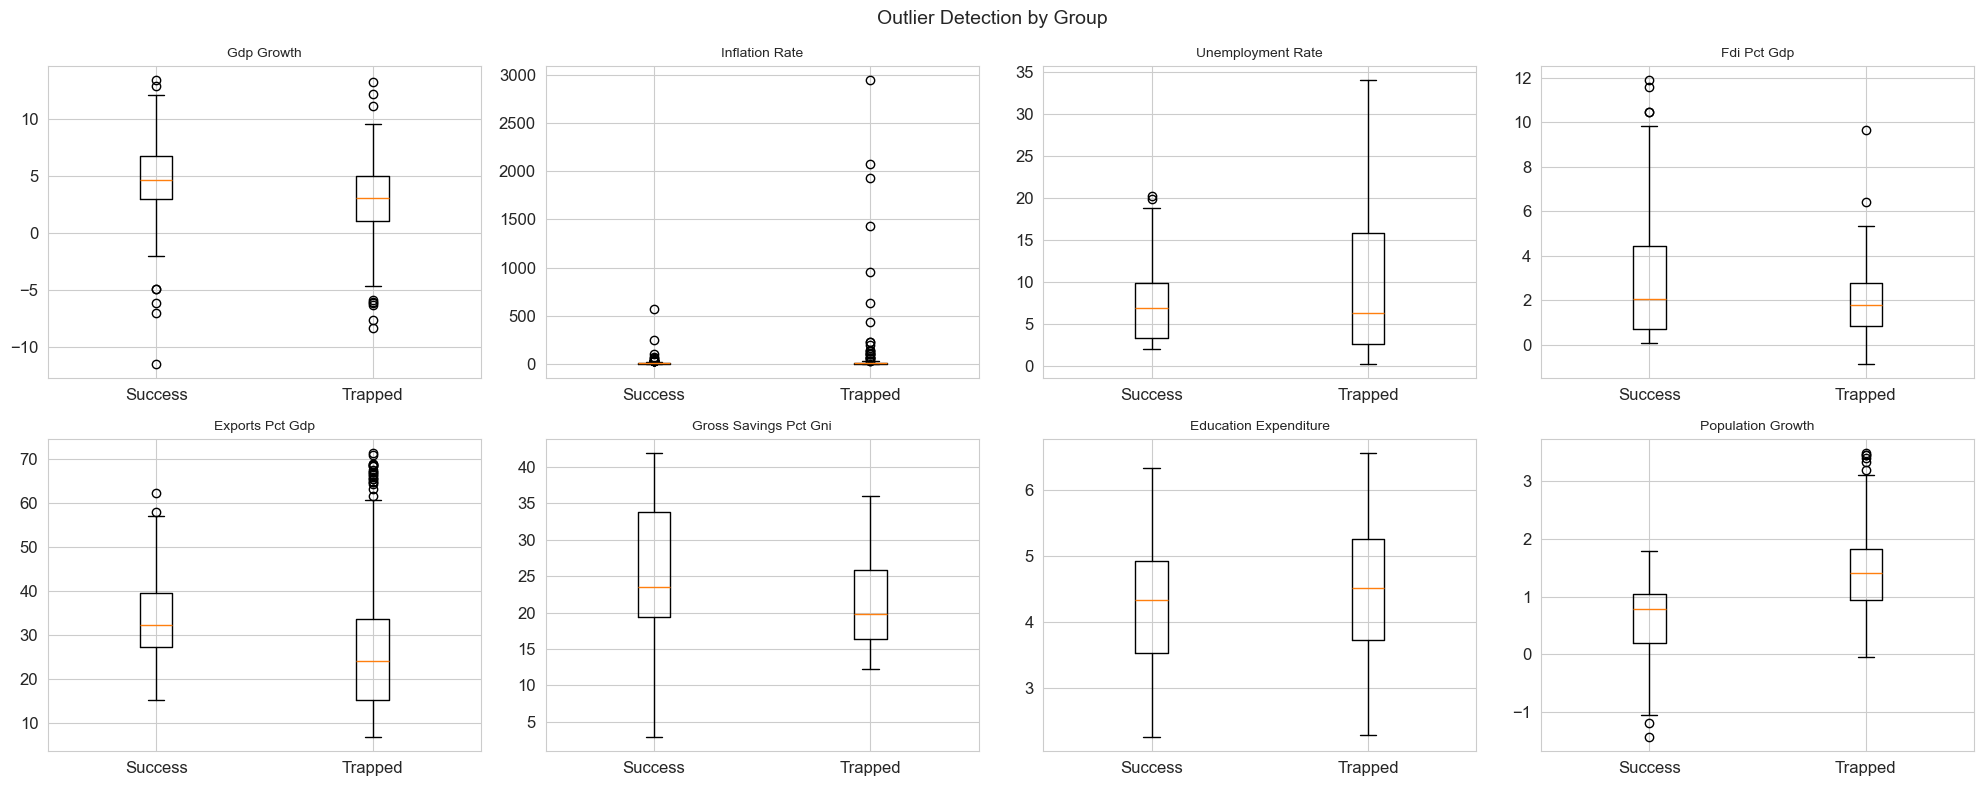


Inflation shows extreme right skew in the Trapped group (Brazil hyperinflation).
Unemployment outliers driven by South Africa and Poland's transition periods.
We retain these as legitimate economic events rather than data errors.

=== IQR-Based Outlier Count by Indicator ===
  gdp_growth                  :  14 outliers
  inflation_rate              :  35 outliers
  unemployment_rate           :  28 outliers
  fdi_pct_gdp                 :   9 outliers
  exports_pct_gdp             :  21 outliers
  gross_savings_pct_gni       :   0 outliers
  population_growth           :  12 outliers

Inflation has the most outliers due to Brazil's hyperinflation (handled via log transform).
All other outliers represent real economic events and are retained.


In [11]:
print("=== GDP Growth Extremes (|growth| > 10%) ===")
extreme = df.loc[
    df['gdp_growth'].abs() > 10,
    ['country', 'year', 'gdp_growth']
].sort_values('gdp_growth')

if len(extreme) > 0:
    print(extreme.to_string(index=False))
    print("\nThese correspond to real events (1980s rapid industrialization, post-COVID rebound).")
    print("We keep them as legitimate data points.")
else:
    print("No extreme values found.")

print("\n=== Inflation Outliers (>100%) ===")
high_inflation = df[df['inflation_rate'] > 100][['country', 'year', 'inflation_rate']]
print(high_inflation.sort_values('inflation_rate', ascending=False).to_string(index=False))
print(f"\n{len(high_inflation)} observations with inflation > 100%.")
print("Brazil's hyperinflation era (1980s-90s) dominates these extremes.")
print("We will handle this via log transformation in feature engineering.")

box_cols = ['gdp_growth', 'inflation_rate', 'unemployment_rate', 'fdi_pct_gdp',
            'exports_pct_gdp', 'gross_savings_pct_gni', 'education_expenditure', 'population_growth']
box_cols = [c for c in box_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, col in enumerate(box_cols):
    ax = axes.flatten()[i]
    data_s = df[df['group'] == 'Success'][col].dropna()
    data_t = df[df['group'] == 'Trapped'][col].dropna()
    ax.boxplot([data_s, data_t], labels=['Success', 'Trapped'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
plt.suptitle('Outlier Detection by Group', fontsize=14)
plt.tight_layout()
plt.show()
print("\nInflation shows extreme right skew in the Trapped group (Brazil hyperinflation).")
print("Unemployment outliers driven by South Africa and Poland's transition periods.")
print("We retain these as legitimate economic events rather than data errors.")

print("\n=== IQR-Based Outlier Count by Indicator ===")
outlier_cols = ['gdp_growth', 'inflation_rate', 'unemployment_rate', 'fdi_pct_gdp',
                'exports_pct_gdp', 'gross_savings_pct_gni', 'population_growth']
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:<28s}: {n_outliers:>3d} outliers")
print("\nInflation has the most outliers due to Brazil's hyperinflation (handled via log transform).")
print("All other outliers represent real economic events and are retained.")

---
## 4. Exploratory Data Analysis

In [12]:
COUNTRY_COLORS = {
    'Korea, Rep.':  '#1a9641',
    'Poland':       '#66bd63',
    'Chile':        '#a6d96a',
    'Brazil':       '#d73027',
    'South Africa': '#f46d43',
    'Mexico':       '#fdae61',
    'Thailand':     '#fee08b'
}

GROUP_COLORS = {'Success': '#1a9641', 'Trapped': '#d73027'}

def plot_by_country(ax, data, y_col, title, ylabel):
    """Plot one line per country. Solid = Success, dashed = Trapped."""
    for country_name, color in COUNTRY_COLORS.items():
        cdata = data[data['country'] == country_name].dropna(subset=[y_col])
        if cdata.empty:
            continue
        is_success = country_name in SUCCESS_LIST
        ax.plot(cdata['year'], cdata[y_col],
                label=country_name, color=color,
                linewidth=2.2, linestyle='-' if is_success else '--')
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)

### 4.1 GDP Per Capita: The Divergence

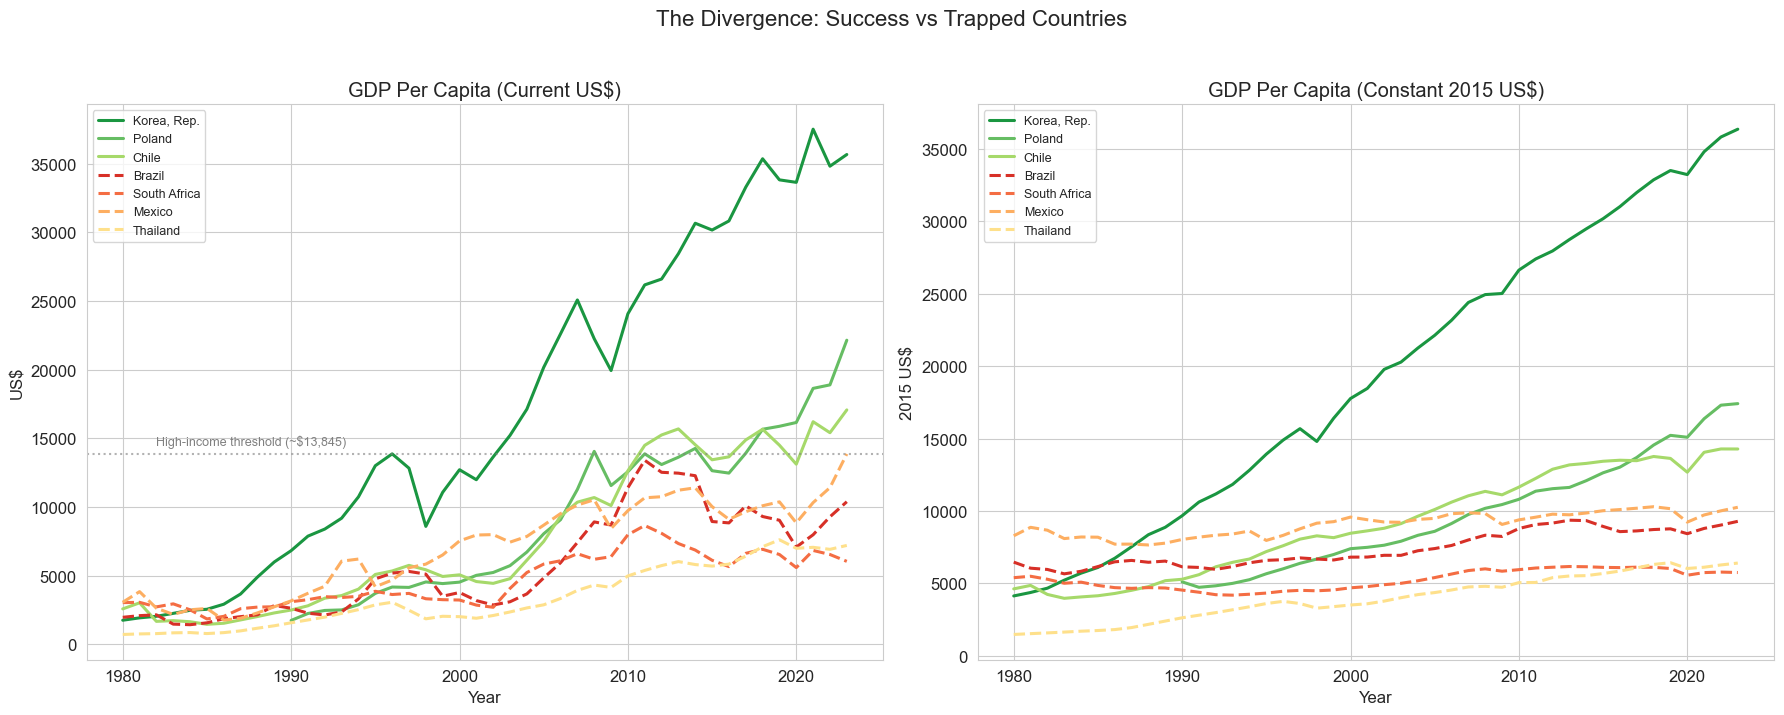

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_by_country(axes[0], df, 'gdp_per_capita',
                'GDP Per Capita (Current US$)', 'US$')
axes[0].axhline(y=13845, color='gray', linestyle=':', alpha=0.6)
axes[0].annotate('High-income threshold (~$13,845)',
                 xy=(1982, 14500), fontsize=9, color='gray')

plot_by_country(axes[1], df, 'gdp_per_capita_const',
                'GDP Per Capita (Constant 2015 US$)', '2015 US$')

plt.suptitle('The Divergence: Success vs Trapped Countries', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The left panel shows that Korea, Poland, and Chile all crossed the high-income threshold (~$13,845) at different times, while Brazil, Mexico, South Africa, and Thailand have plateaued below it. In constant 2015 dollars (right panel), Korea's trajectory is striking: it was at roughly the same level as Thailand and Mexico in 1980, but by 2023 it had reached 5x their level. The divergence is gradual through the 1990s and accelerates sharply after 2000.

### 4.2 GDP Growth: Speed vs Consistency

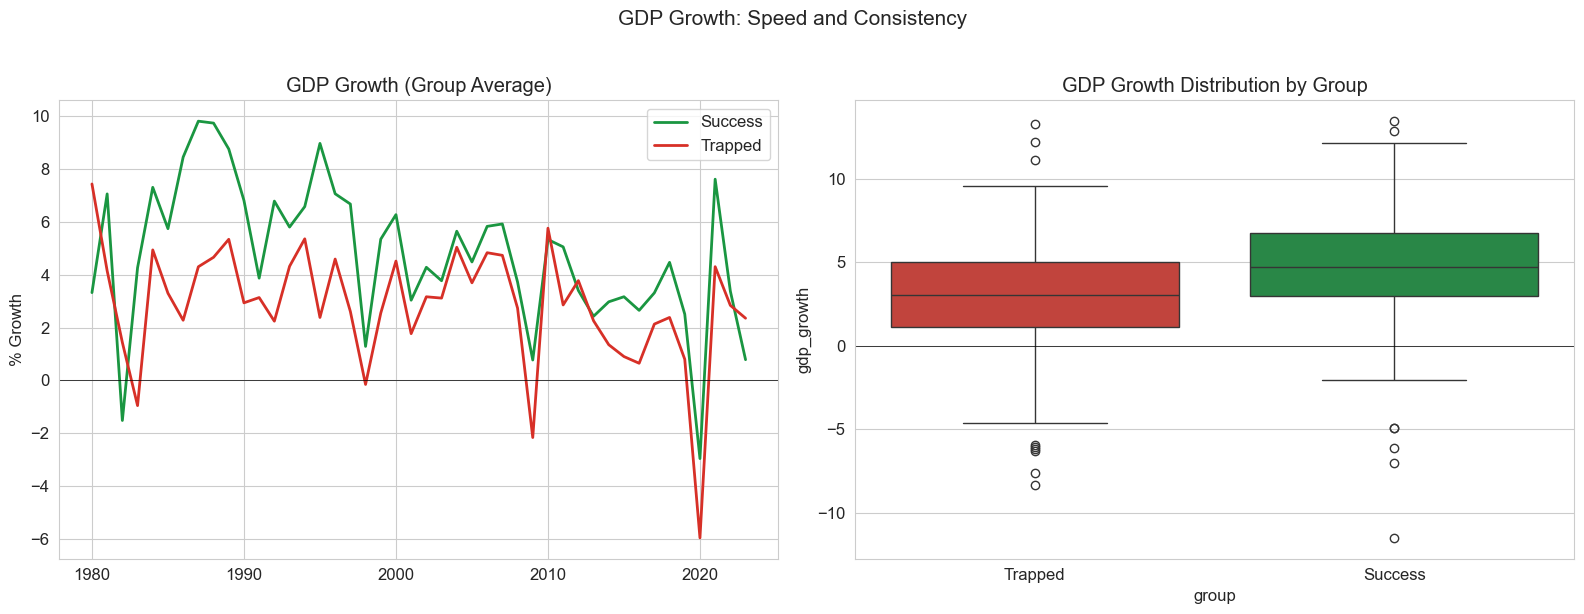


=== Key Indicators by Decade and Group ===
                gdp_per_capita  gdp_growth  tertiary_enrollment  \
decade group                                                      
1980   Success          2501.4         6.3                  NaN   
       Trapped          1999.5         3.7                 10.9   
1990   Success          5925.7         5.9                  NaN   
       Trapped          3583.1         3.0                 13.0   
2000   Success         11158.8         4.4                 68.0   
       Trapped          5424.0         3.1                 33.0   
2010   Success         19403.5         3.5                 83.6   
       Trapped          8561.4         2.3                 38.0   
2020   Success         23273.2         2.2                 91.0   
       Trapped          8265.8         0.9                 41.6   

                manufacturing_pct_gdp  
decade group                           
1980   Success                   22.1  
       Trapped                 

In [14]:
df['decade'] = (df['year'] // 10) * 10

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

grp_growth = df.groupby(['year', 'group'])['gdp_growth'].mean().reset_index()
for grp, color in GROUP_COLORS.items():
    subset = grp_growth[grp_growth['group'] == grp]
    axes[0].plot(subset['year'], subset['gdp_growth'], label=grp, color=color, linewidth=2)
axes[0].axhline(y=0, color='black', linewidth=0.5)
axes[0].set_title('GDP Growth (Group Average)')
axes[0].set_ylabel('% Growth')
axes[0].legend()

sns.boxplot(data=df, x='group', y='gdp_growth', palette=GROUP_COLORS, ax=axes[1])
axes[1].set_title('GDP Growth Distribution by Group')
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('GDP Growth: Speed and Consistency', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== Key Indicators by Decade and Group ===")
decade_compare = (
    df.groupby(['decade', 'group'])
    [['gdp_per_capita', 'gdp_growth', 'tertiary_enrollment', 'manufacturing_pct_gdp']]
    .mean().round(1)
)
print(decade_compare)
print("\nThe GDP per capita gap widens sharply from the 2000s onward.")
print("Tertiary enrollment divergence accelerates each decade.")

The group average growth chart shows that success countries consistently grew 1–3 percentage points faster per year. This gap looks small annually, but compounding over 40 years produces the dramatic GDP divergence we saw above. The decade boxplots reveal that both groups experienced negative growth episodes, but success countries recovered faster and returned to higher baselines. Growth volatility is comparable — the difference is in the level, not the variability.

### 4.3 Economic Structure: Industry, Manufacturing, Services

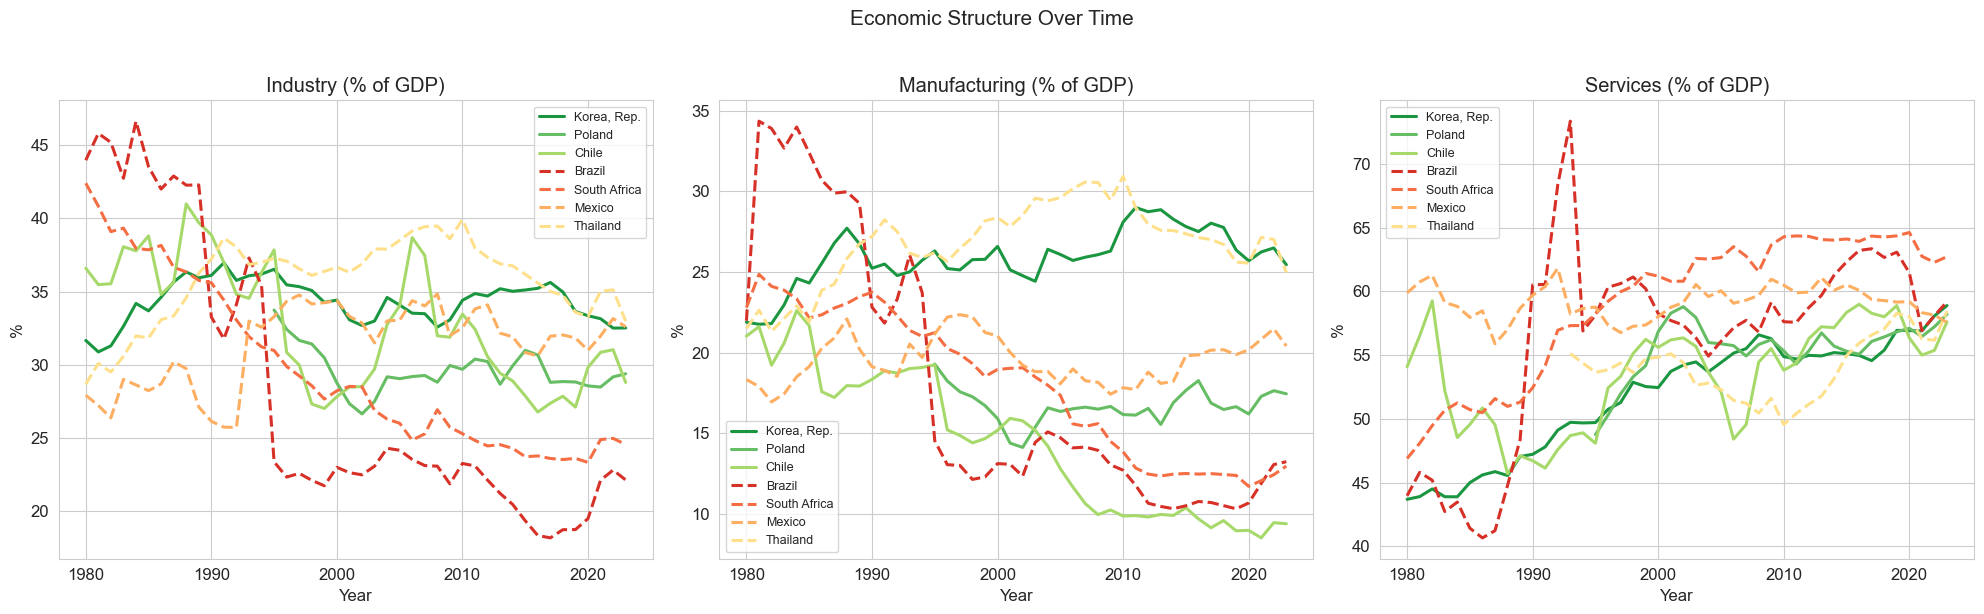

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_by_country(axes[0], df, 'industry_pct_gdp', 'Industry (% of GDP)', '%')
plot_by_country(axes[1], df, 'manufacturing_pct_gdp', 'Manufacturing (% of GDP)', '%')
plot_by_country(axes[2], df, 'services_pct_gdp', 'Services (% of GDP)', '%')

plt.suptitle('Economic Structure Over Time', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Industry's share of GDP has declined across all seven countries, following a global shift toward services. The key difference is in manufacturing specifically: Korea maintained a high manufacturing base (25%+) well into the 2000s while simultaneously expanding services. Trapped countries lost manufacturing share earlier and shifted toward lower-productivity services. This suggests that premature deindustrialization may be part of the trap.

### 4.4 Human Capital: Education

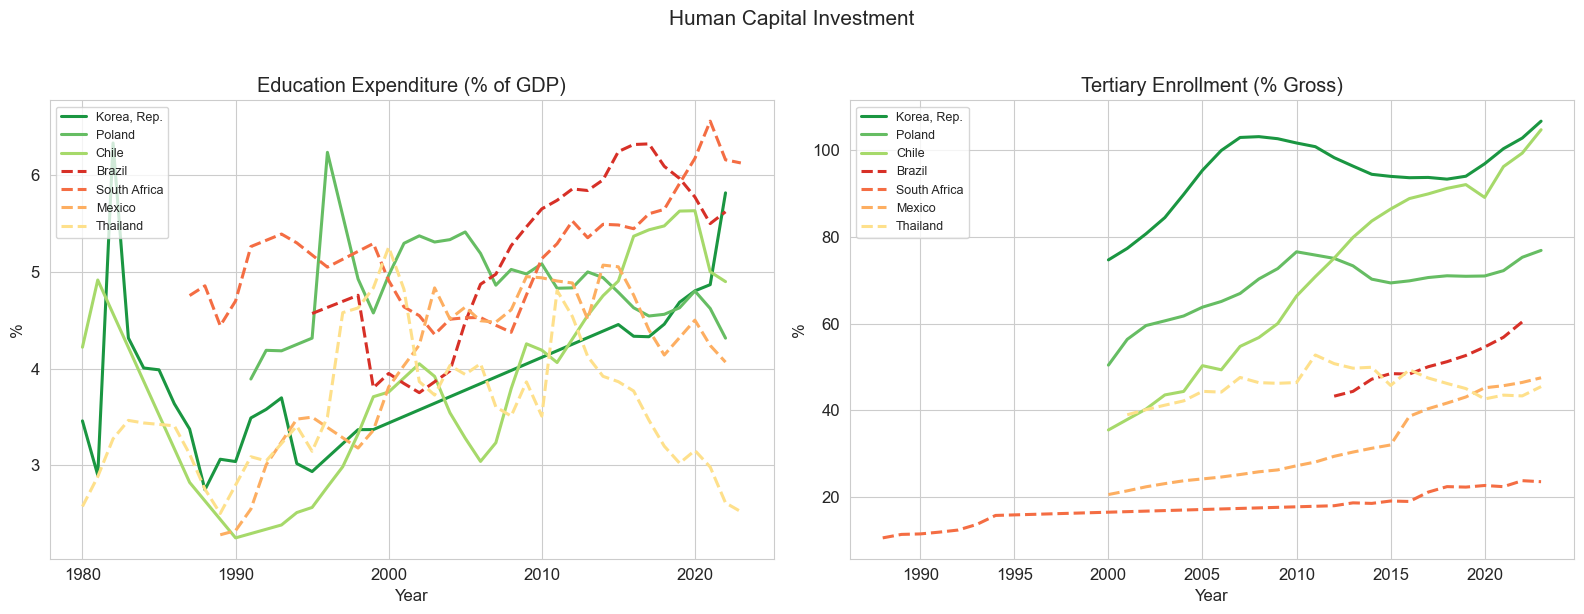

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_by_country(axes[0], df, 'education_expenditure',
                'Education Expenditure (% of GDP)', '%')
plot_by_country(axes[1], df, 'tertiary_enrollment',
                'Tertiary Enrollment (% Gross)', '%')

plt.suptitle('Human Capital Investment', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Education shows the single largest gap. Korea's tertiary enrollment passed 100% (meaning more enrolled than the age-appropriate cohort, due to adult learners), while no trapped country exceeds 55%. Education expenditure as a share of GDP is surprisingly similar between groups (~4.3% vs 4.4%), which suggests the issue isn't spending levels but rather the accumulation of human capital over decades. This is the most policy-relevant finding for current middle-income countries.

### 4.5 Trade, FDI, and Savings

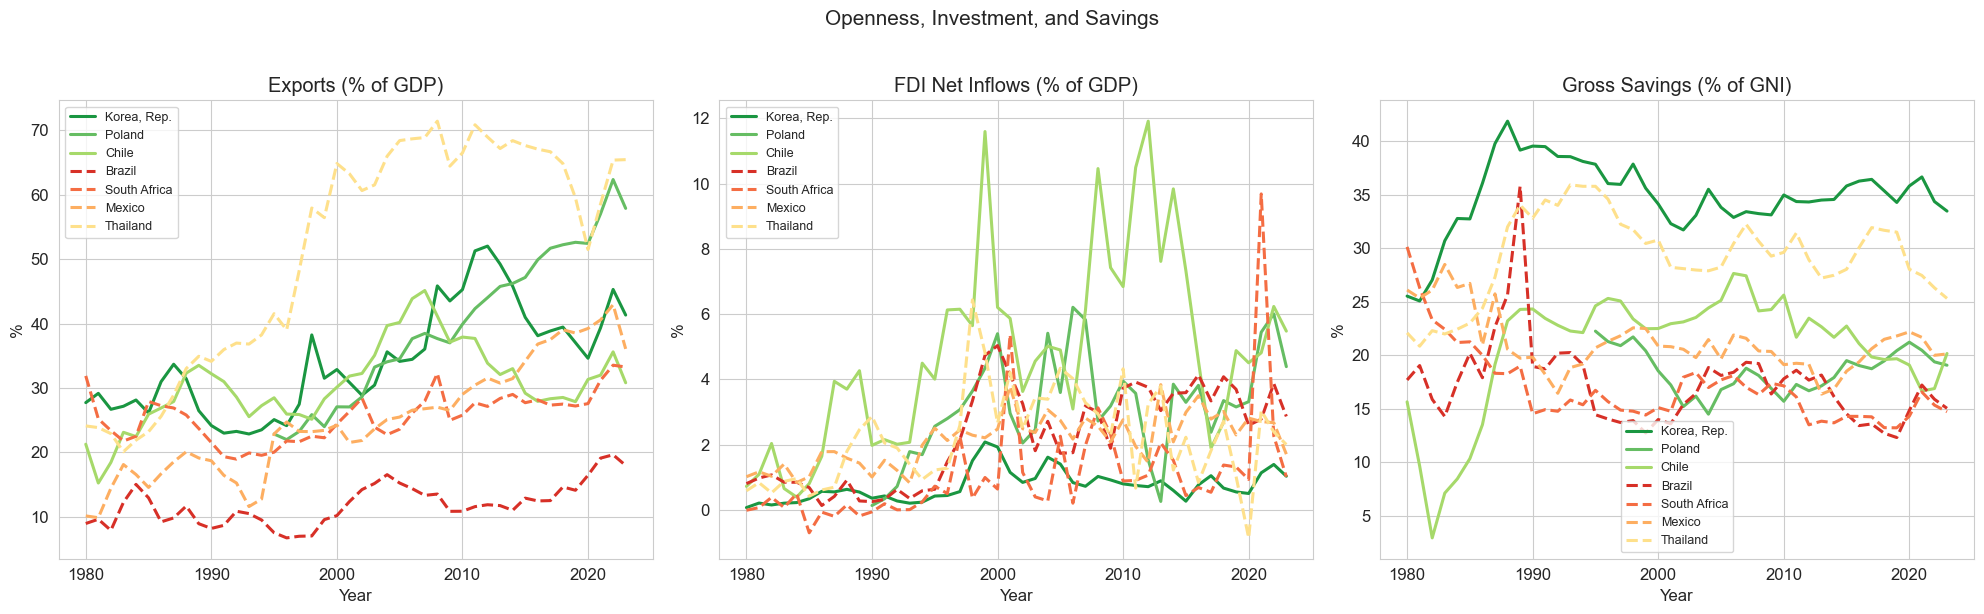

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_by_country(axes[0], df, 'exports_pct_gdp', 'Exports (% of GDP)', '%')
plot_by_country(axes[1], df, 'fdi_pct_gdp', 'FDI Net Inflows (% of GDP)', '%')
plot_by_country(axes[2], df, 'gross_savings_pct_gni', 'Gross Savings (% of GNI)', '%')

plt.suptitle('Openness, Investment, and Savings', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Exports as a share of GDP are consistently higher for success countries, particularly Korea and Chile. More importantly, success countries maintain higher gross savings rates (25.5% vs 21.2% of GNI), meaning they fund growth domestically rather than relying on volatile foreign capital. FDI shows less clear differentiation — trapped countries actually receive comparable FDI, but without the institutional environment to convert it into sustained growth.

### 4.6 Macro Stability: Inflation, Unemployment, Debt

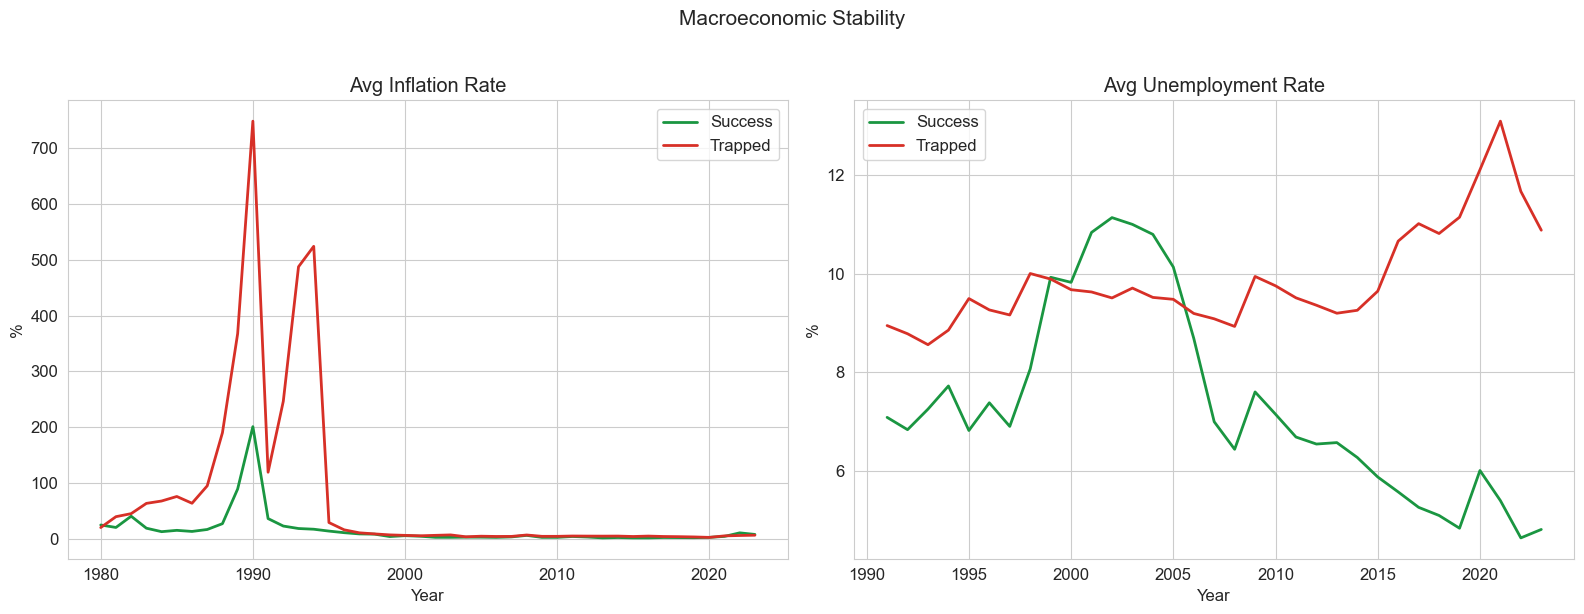

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (col, title) in enumerate([
    ('inflation_rate', 'Avg Inflation Rate'),
    ('unemployment_rate', 'Avg Unemployment Rate')
]):
    gdata = df.groupby(['year', 'group'])[col].mean().reset_index()
    for grp, color in GROUP_COLORS.items():
        subset = gdata[gdata['group'] == grp]
        axes[idx].plot(subset['year'], subset[col], label=grp, color=color, linewidth=2)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Year')
    axes[idx].set_ylabel('%')
    axes[idx].legend()

plt.suptitle('Macroeconomic Stability', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Inflation tells a dramatic story. Brazil's hyperinflation era (peaking near 3,000% in the early 1990s) dominates the trapped group's average, but even excluding Brazil, trapped countries ran higher and more volatile inflation. Unemployment shows a similar pattern: South Africa's structural unemployment (consistently above 20%) pulls the trapped average well above the success group. Both indicators point to an environment hostile to long-term capital investment.

### 4.7 Correlation Heatmaps by Group

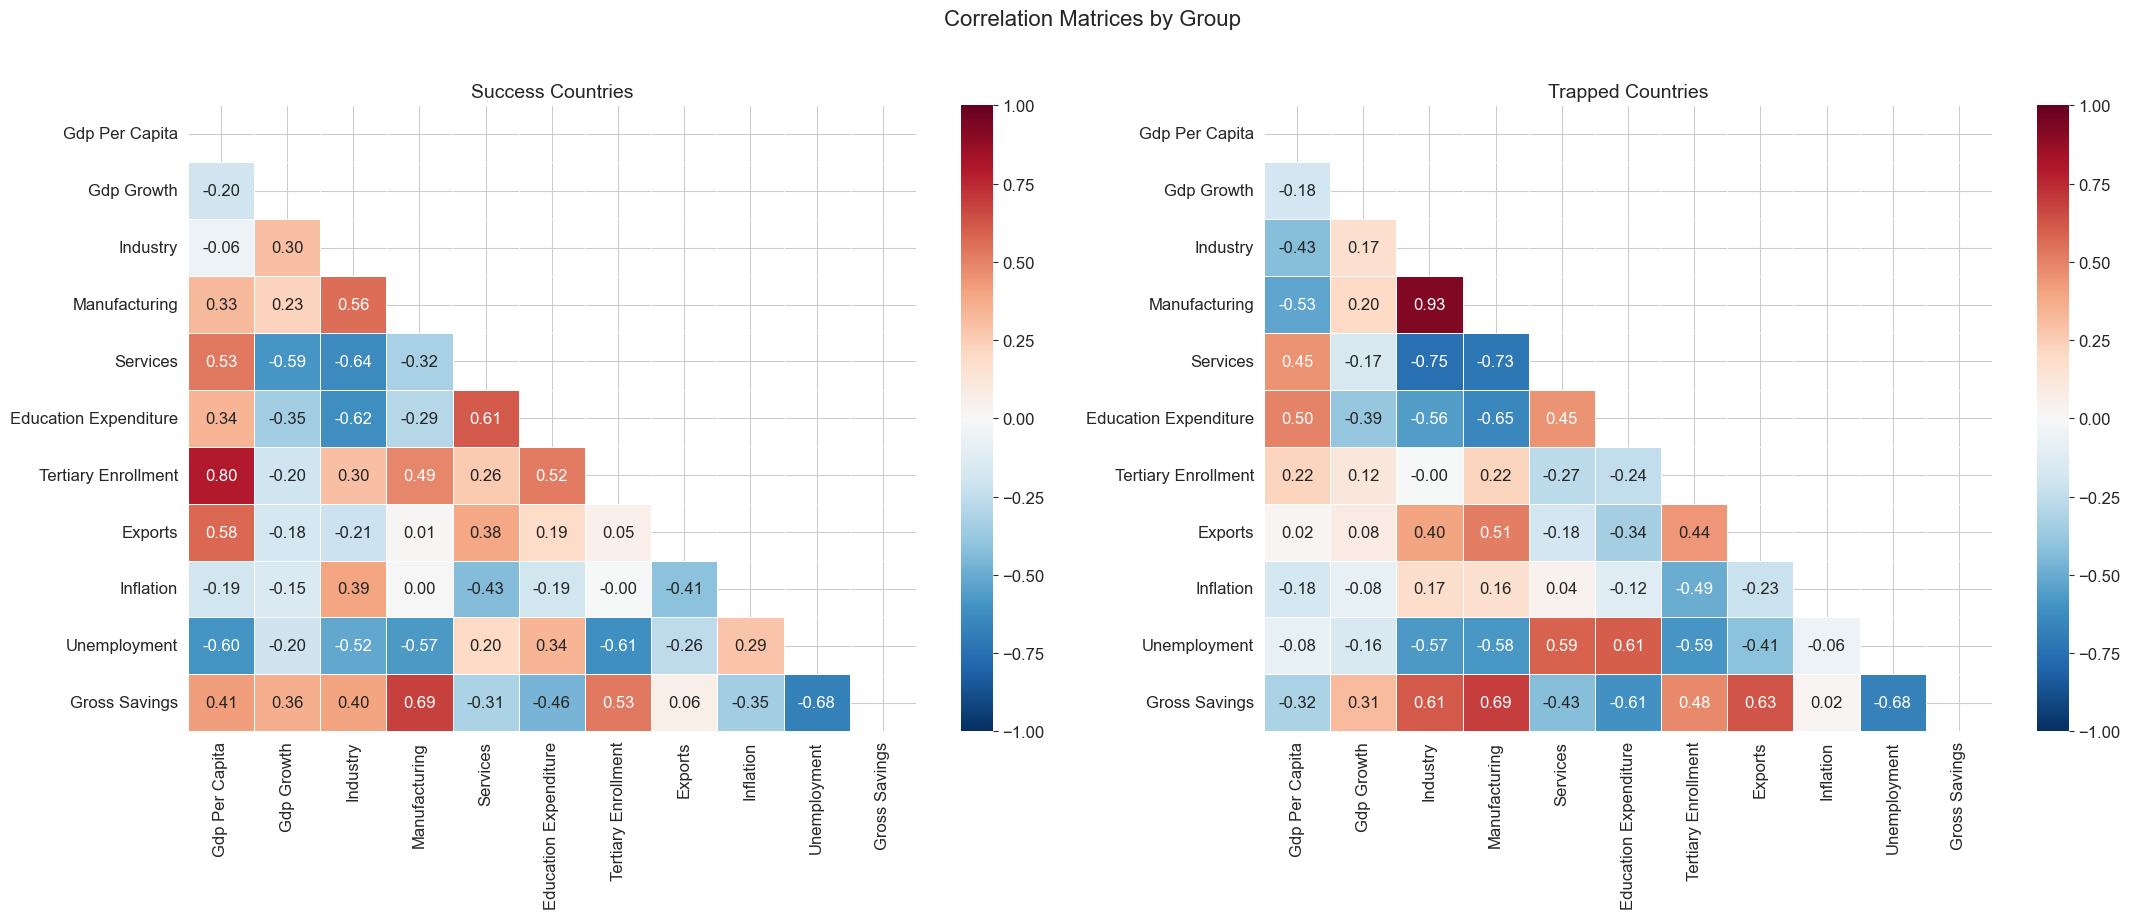

In [19]:
corr_cols = ['gdp_per_capita', 'gdp_growth', 'industry_pct_gdp', 'manufacturing_pct_gdp',
             'services_pct_gdp', 'education_expenditure', 'tertiary_enrollment',
             'exports_pct_gdp', 'inflation_rate', 'unemployment_rate', 'gross_savings_pct_gni']
corr_cols = [c for c in corr_cols if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for idx, group in enumerate(['Success', 'Trapped']):
    corr = df[df['group'] == group][corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    labels = [c.replace('_pct_gdp', '').replace('_pct_gni', '')
              .replace('_rate', '').replace('_', ' ').title() for c in corr.columns]
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=axes[idx], linewidths=0.5,
                xticklabels=labels, yticklabels=labels)
    axes[idx].set_title(f'{group} Countries', fontsize=14)

plt.suptitle('Correlation Matrices by Group', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The split heatmaps reveal structurally different economies. In the Success group, tertiary enrollment correlates strongly with GDP per capita (r ≈ 0.8+), reflecting how education investment translated into income growth. In the Trapped group, this relationship is weaker, and inflation shows stronger negative correlations across most indicators — macro instability disrupts the education-to-growth pipeline. This motivates our macro instability composite feature.

### 4.8 Pairplot: Key Relationships

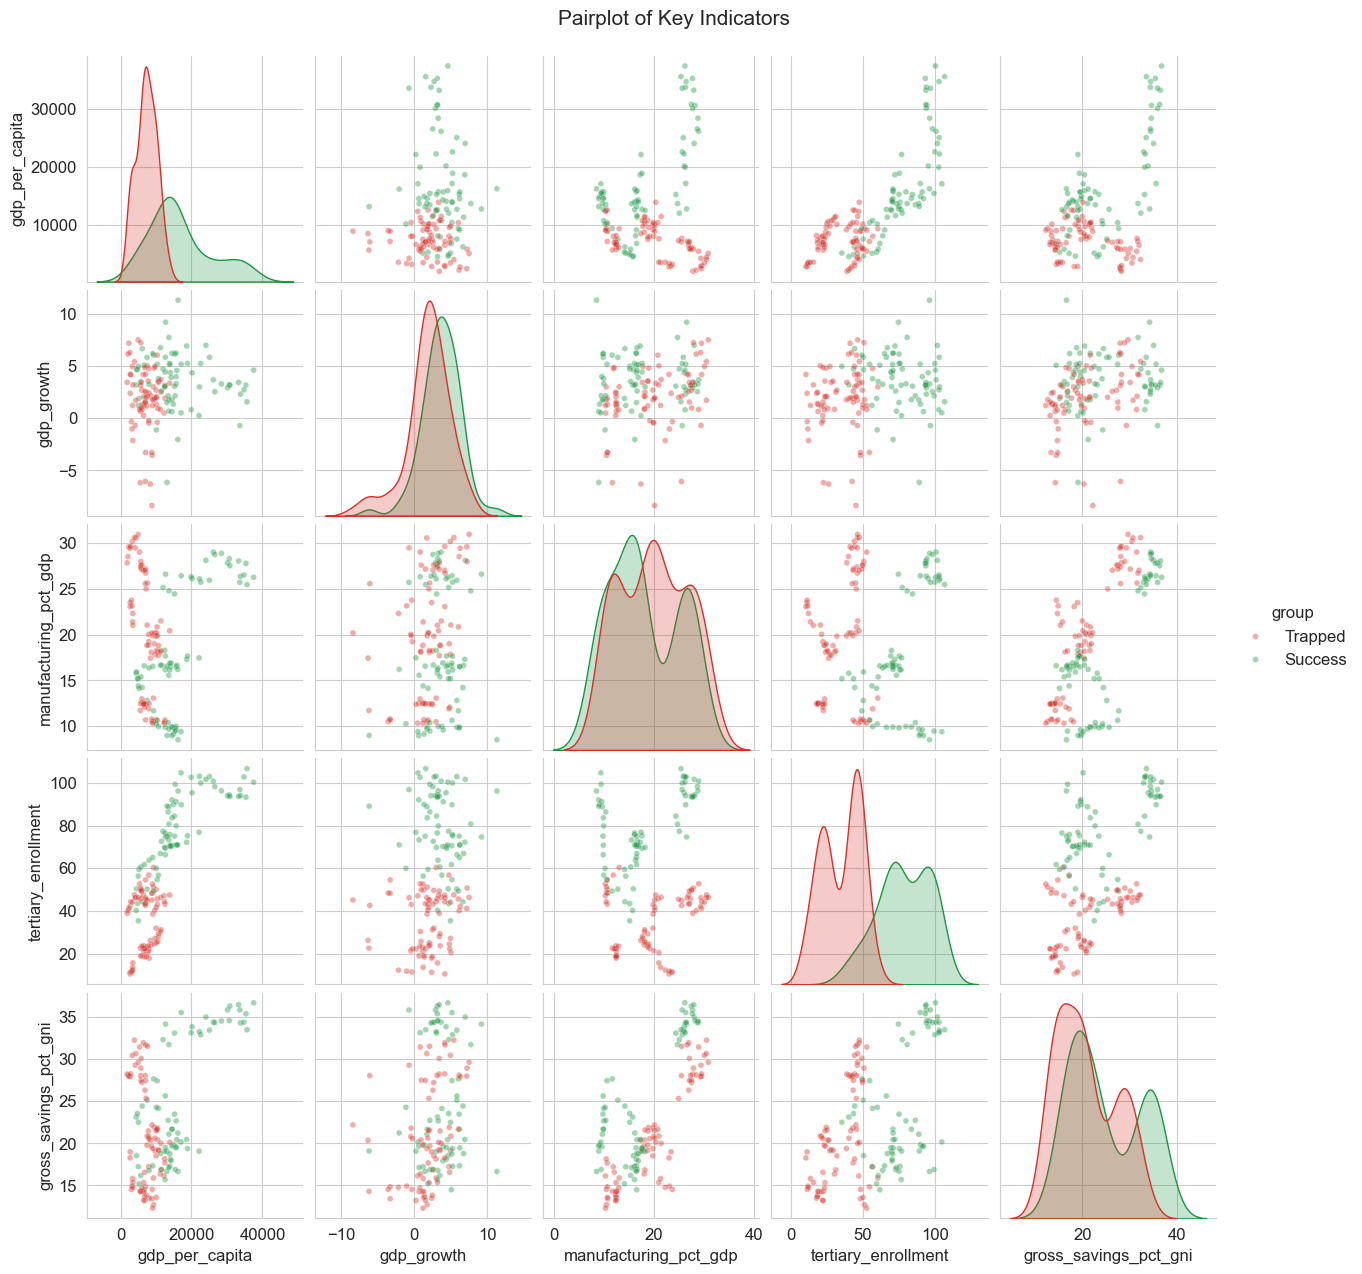

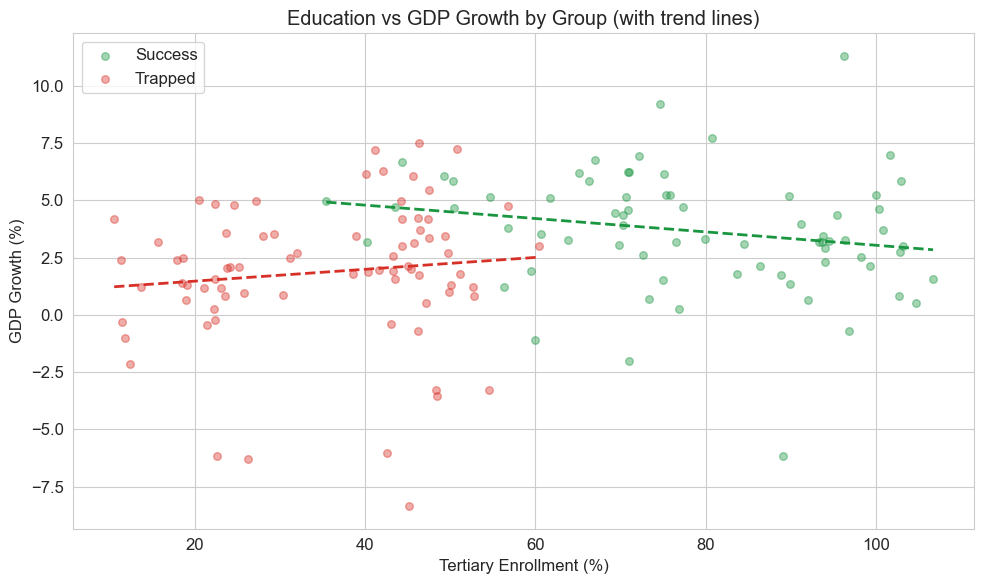

Success countries maintain higher growth across all education levels.
Both groups show similar slopes, but the Success group has a higher intercept.


In [20]:
pair_cols = ['gdp_per_capita', 'gdp_growth', 'manufacturing_pct_gdp',
             'tertiary_enrollment', 'gross_savings_pct_gni', 'group']
pair_cols = [c for c in pair_cols if c in df.columns]

g = sns.pairplot(df[pair_cols].dropna(), hue='group', diag_kind='kde',
                 palette=GROUP_COLORS, plot_kws={'alpha': 0.4, 's': 18})
g.figure.suptitle('Pairplot of Key Indicators', y=1.02, fontsize=15)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for grp, color in GROUP_COLORS.items():
    sub = df[df['group'] == grp].dropna(subset=['tertiary_enrollment', 'gdp_growth'])
    ax.scatter(sub['tertiary_enrollment'], sub['gdp_growth'],
              c=color, label=grp, alpha=0.4, s=30)
    z = np.polyfit(sub['tertiary_enrollment'], sub['gdp_growth'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(sub['tertiary_enrollment'].min(), sub['tertiary_enrollment'].max(), 50)
    ax.plot(x_range, p(x_range), color=color, linewidth=2, linestyle='--')
ax.set_xlabel('Tertiary Enrollment (%)')
ax.set_ylabel('GDP Growth (%)')
ax.legend()
ax.set_title('Education vs GDP Growth by Group (with trend lines)')
plt.tight_layout()
plt.show()
print("Success countries maintain higher growth across all education levels.")
print("Both groups show similar slopes, but the Success group has a higher intercept.")

The pairplot confirms several patterns from our individual charts. GDP per capita and tertiary enrollment show the clearest separation between groups, with almost no overlap in the upper ranges. The scatter of GDP growth vs manufacturing shows both groups occupy similar ranges, suggesting manufacturing alone doesn't drive the divergence — it needs to be paired with education and governance, which we test in feature engineering.

---
## 5. External Dataset: Governance Quality

The World Bank's Worldwide Governance Indicators (available from 1996) measure institutional quality across four dimensions. Since governance is often cited as a key factor in development traps, we pull this as a separate dataset and merge it in.

In [21]:
GOVERNANCE_INDICATORS = {
    'CC.EST': 'control_of_corruption',
    'RL.EST': 'rule_of_law',
    'GE.EST': 'govt_effectiveness',
    'RQ.EST': 'regulatory_quality'
}

print("Downloading governance indicators (external dataset)...")
print("=" * 55)

gov_dfs = {}
for ind_code, col_name in GOVERNANCE_INDICATORS.items():
    records = fetch_wb_indicator(ind_code, COUNTRIES_STR, 1996, END_YEAR)
    if not records:
        continue
    df_raw = pd.json_normalize(records)
    df_clean = df_raw[['country.value', 'date', 'value']].copy()
    df_clean.columns = ['country', 'year', col_name]
    df_clean['year'] = df_clean['year'].astype(int)
    gov_dfs[col_name] = df_clean

gov_names = list(gov_dfs.keys())
df_gov = gov_dfs[gov_names[0]]
for name in gov_names[1:]:
    df_gov = df_gov.merge(gov_dfs[name], on=['country', 'year'], how='outer')

df = df.merge(df_gov, on=['country', 'year'], how='left')

gov_cols = list(GOVERNANCE_INDICATORS.values())
print(f"\nGovernance data merged. Shape: {df.shape}")

  CC.EST                         ->  196 records
  RL.EST                         ->  196 records
  GE.EST                         ->  196 records
  RQ.EST                         ->  196 records

Governance data merged. Shape: (308, 23)


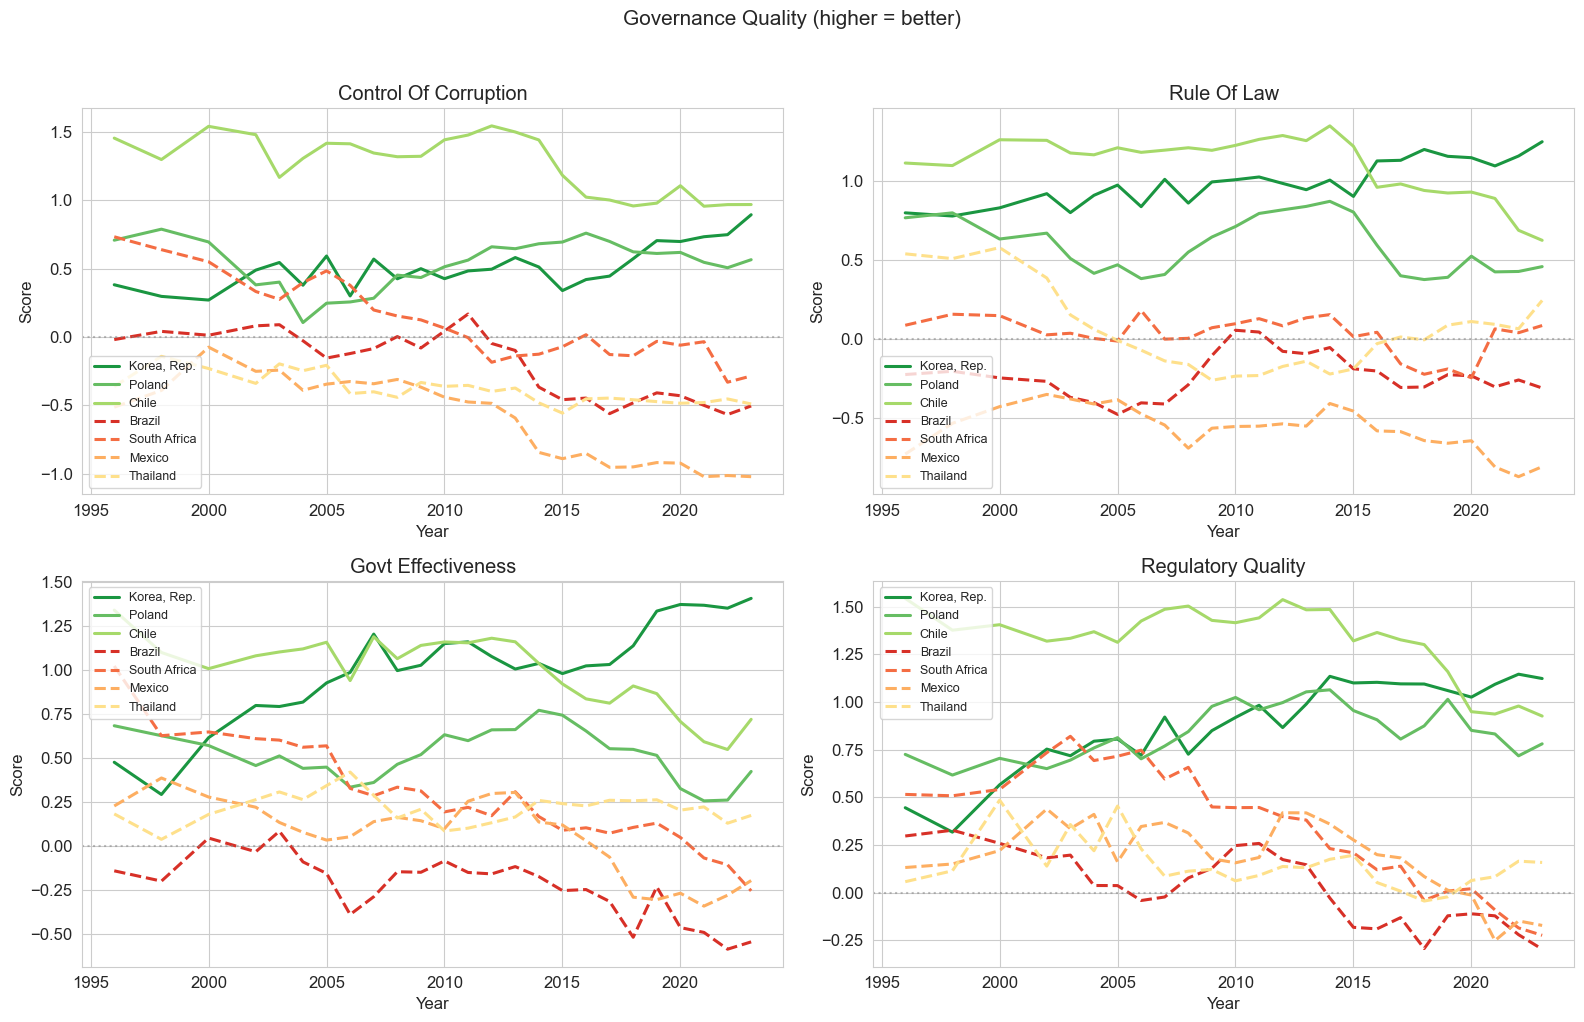

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(gov_cols):
    ax = axes.flatten()[i]
    plot_by_country(ax, df, col, col.replace('_', ' ').title(), 'Score')
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Governance Quality (higher = better)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
gov_avg = df.groupby('group')[gov_cols].mean().round(3).T
gov_avg['gap'] = (gov_avg['Success'] - gov_avg['Trapped']).round(3)
print("=== Average Governance Scores ===")
print(gov_avg)
print("\nSuccess group scores higher across all governance dimensions.")

=== Average Governance Scores ===
group                  Success  Trapped    gap
control_of_corruption    0.771   -0.266  1.037
rule_of_law              0.895   -0.182  1.077
govt_effectiveness       0.841    0.078  0.763
regulatory_quality       1.020    0.178  0.842

Success group scores higher across all governance dimensions.


Success countries score 0.7 to 1.0 points higher across all four governance dimensions — and this gap is remarkably stable over time. Unlike economic indicators, which fluctuate with business cycles, governance differences persist decade after decade. This makes institutional quality the most consistent predictor of group membership, and the hardest for trapped countries to change quickly.

---
## 5B. External Dataset: Innovation & R&D

Our midterm identified R&D and innovation capacity as a gap worth investigating. We now pull three innovation indicators from the World Bank API to test whether technology investment separates the two groups.

In [24]:
INNOVATION_INDICATORS = {
    'GB.XPD.RSDV.GD.ZS': 'rd_pct_gdp',
    'IP.PAT.RESD':        'patent_applications',
    'TX.VAL.TECH.MF.ZS':  'hightech_exports_pct'
}

print("Downloading innovation indicators (new dataset)...")
print("=" * 55)

innov_dfs = {}
for ind_code, col_name in INNOVATION_INDICATORS.items():
    records = fetch_wb_indicator(ind_code, COUNTRIES_STR, START_YEAR, END_YEAR)
    if not records:
        continue
    df_raw = pd.json_normalize(records)
    df_clean = df_raw[['country.value', 'date', 'value']].copy()
    df_clean.columns = ['country', 'year', col_name]
    df_clean['year'] = df_clean['year'].astype(int)
    innov_dfs[col_name] = df_clean

for col_name, idf in innov_dfs.items():
    df = df.merge(idf, on=['country', 'year'], how='left')

innov_cols = list(INNOVATION_INDICATORS.values())
print(f"\nNew columns added: {innov_cols}")
print(f"\nMissing values in innovation indicators:")
print(df[innov_cols].isnull().sum())

  GB.XPD.RSDV.GD.ZS              ->  308 records
  IP.PAT.RESD                    ->  308 records
  TX.VAL.TECH.MF.ZS              ->  308 records

New columns added: ['rd_pct_gdp', 'patent_applications', 'hightech_exports_pct']

Missing values in innovation indicators:
rd_pct_gdp              144
patent_applications      14
hightech_exports_pct    190
dtype: int64


=== Average Innovation Indicators ===
group                   Success   Trapped        gap
rd_pct_gdp                1.698     0.642      1.056
patent_applications   28308.270  1590.327  26717.943
hightech_exports_pct     16.308    15.956      0.352


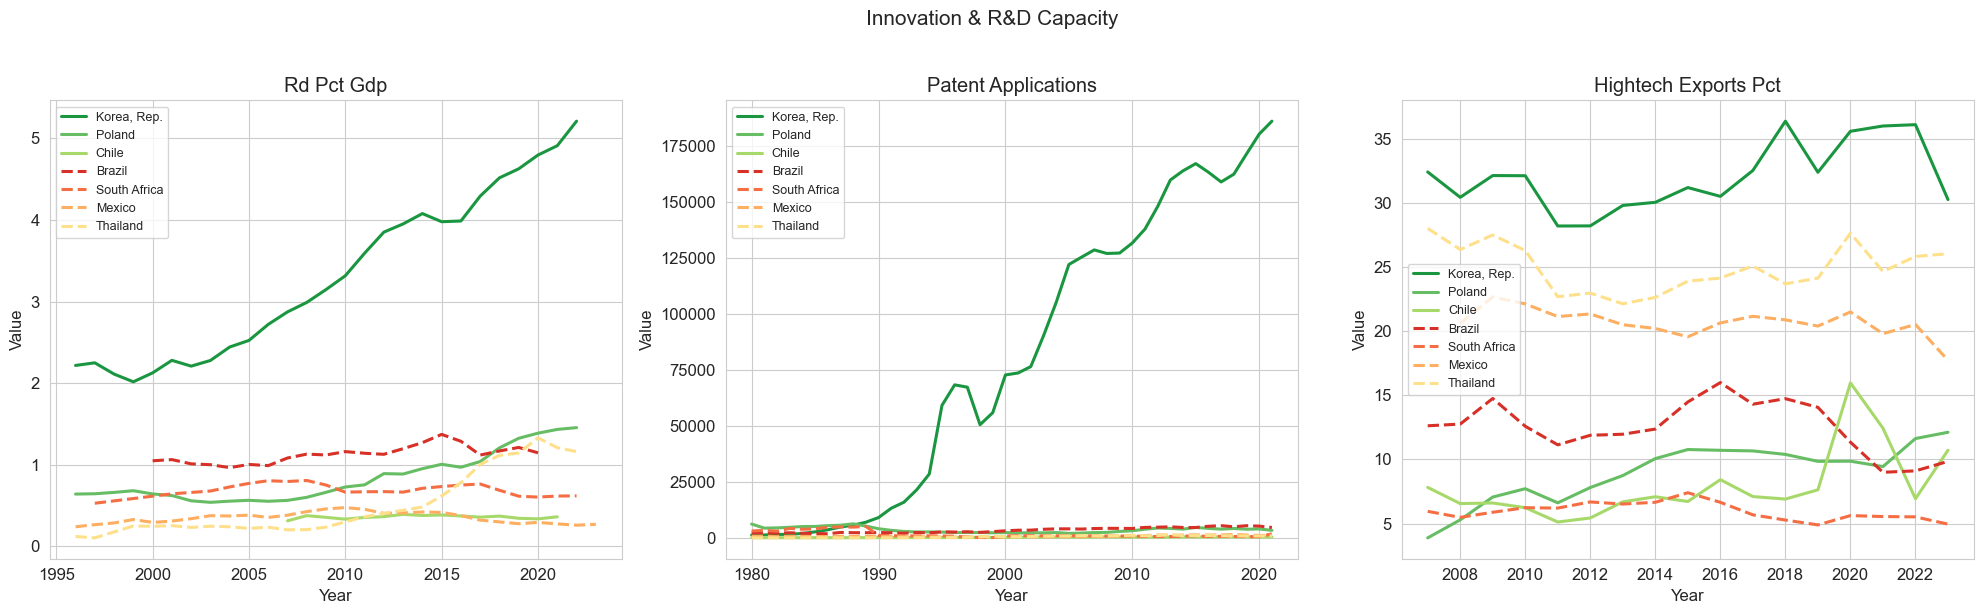

In [25]:
innov_avg = df.groupby('group')[innov_cols].mean().round(3).T
innov_avg['gap'] = (innov_avg['Success'] - innov_avg['Trapped']).round(3)
print("=== Average Innovation Indicators ===")
print(innov_avg)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, col in enumerate(innov_cols):
    plot_by_country(axes[i], df, col, col.replace('_', ' ').title(), 'Value')
plt.suptitle('Innovation & R&D Capacity', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

R&D spending and patent activity show enormous gaps. Korea alone spends over 4% of GDP on R&D and files 200,000+ patents annually — more than all four trapped countries combined. High-tech export share is surprisingly similar between groups, suggesting trapped countries participate in global tech supply chains but as assemblers, not innovators. The R&D gap is arguably the strongest leading indicator of divergence.

---
## 6. Feature Engineering

We create new variables that capture dynamics the raw indicators miss — rolling averages to smooth volatility, ratios to capture structural composition, composites to combine related metrics, and interaction terms to test whether combinations matter more than individual factors.

In [26]:
df = df.sort_values(['country', 'year']).reset_index(drop=True)

df['growth_5yr_avg'] = (
    df.groupby('country')['gdp_growth']
    .transform(lambda x: x.rolling(5, min_periods=3).mean())
)

df['growth_acceleration'] = df.groupby('country')['gdp_growth'].diff()

df['manufacturing_intensity'] = (
    df['manufacturing_pct_gdp'] / df['industry_pct_gdp']
).replace([np.inf, -np.inf], np.nan)

df['service_industry_ratio'] = (
    df['services_pct_gdp'] / df['industry_pct_gdp']
).replace([np.inf, -np.inf], np.nan)

df['edu_per_capita_proxy'] = (df['education_expenditure'] / 100) * df['gdp_per_capita']

df['macro_instability'] = df['inflation_rate'].abs() + df['unemployment_rate']

df['savings_minus_fdi'] = df['gross_savings_pct_gni'] - df['fdi_pct_gdp']

df['gdp_pc_yoy_growth'] = (
    df.groupby('country')['gdp_per_capita_const'].pct_change() * 100
)

new_features = ['growth_5yr_avg', 'growth_acceleration', 'manufacturing_intensity',
                'service_industry_ratio', 'edu_per_capita_proxy', 'macro_instability',
                'savings_minus_fdi', 'gdp_pc_yoy_growth']

print("=== Engineered Features ===")
df[new_features].describe().round(2)

=== Engineered Features ===


,growth_5yr_avg,growth_acceleration,manufacturing_intensity,service_industry_ratio,edu_per_capita_proxy,macro_instability,savings_minus_fdi,gdp_pc_yoy_growth
count,283.00,290.00,293.00,280.00,217.00,231.00,293.00,291.00
mean,3.61,-0.06,0.62,1.84,363.55,38.64,20.54,2.38
std,2.54,4.24,0.12,0.49,325.30,197.06,8.03,3.90
min,-0.70,-18.22,0.28,0.93,18.25,0.88,0.89,-12.78
25%,1.93,-2.04,0.55,1.47,141.19,7.01,14.73,0.60
50%,3.21,-0.18,0.62,1.77,270.54,12.39,18.38,2.57
75%,4.81,1.56,0.72,2.08,474.16,21.02,25.62,4.78
max,11.29,17.46,0.83,3.48,2024.74,2082.47,41.26,11.81


In [27]:
med_tertiary = df['tertiary_enrollment'].median()
med_manuf = df['manufacturing_pct_gdp'].median()

df['high_edu_high_manuf'] = (
    (df['tertiary_enrollment'] > med_tertiary) &
    (df['manufacturing_pct_gdp'] > med_manuf)
).astype(int)

print(f"Median tertiary enrollment : {med_tertiary:.1f}%")
print(f"Median manufacturing % GDP : {med_manuf:.1f}%")
print(f"\nProportion with BOTH above median:")
print(df.groupby('group')['high_edu_high_manuf'].mean().round(3))

Median tertiary enrollment : 50.0%
Median manufacturing % GDP : 19.8%

Proportion with BOTH above median:
group
Success    0.182
Trapped    0.011
Name: high_edu_high_manuf, dtype: float64


In [28]:
def classify_income(gdp_pc):
    if pd.isna(gdp_pc):   return 'Unknown'
    if gdp_pc < 1136:     return 'Low'
    if gdp_pc < 4466:     return 'Lower-Middle'
    if gdp_pc < 13845:    return 'Upper-Middle'
    return 'High'

df['income_class'] = df['gdp_per_capita'].apply(classify_income)
income_dummies = pd.get_dummies(df['income_class'], prefix='inc', dtype=int)
df = pd.concat([df, income_dummies], axis=1)

years_in_class = (
    df[df['income_class'] != 'Unknown']
    .groupby(['country', 'income_class']).size()
    .unstack(fill_value=0)
)
print("=== Years in Each Income Class ===")
print(years_in_class)

=== Years in Each Income Class ===
income_class  High  Low  Lower-Middle  Upper-Middle
country                                            
Brazil           0    0            21            23
Chile           10    0            16            18
Korea, Rep.     22    0             8            14
Mexico           1    0            14            29
Poland          10    0             9            15
South Africa     0    0            24            20
Thailand         0    8            22            14


### 6.1 Feature Scaling (Min-Max)

In [29]:
scale_cols = ['gdp_per_capita', 'gdp_growth', 'manufacturing_pct_gdp',
              'tertiary_enrollment', 'exports_pct_gdp', 'gross_savings_pct_gni',
              'manufacturing_intensity', 'macro_instability']
scale_cols = [c for c in scale_cols if c in df.columns]

to_scale = df[scale_cols].copy()

# FIX 1
to_scale['macro_instability'] = np.log1p(to_scale['macro_instability'])

# FIX 2
to_scale['tertiary_enrollment'] = (
    df.groupby('country')['tertiary_enrollment']
    .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
)

to_scale = to_scale.fillna(to_scale.median())

scaler = MinMaxScaler()
scaled_arr = scaler.fit_transform(to_scale)
scaled_df = pd.DataFrame(scaled_arr, columns=[f'{c}_scaled' for c in scale_cols], index=df.index)
df = pd.concat([df, scaled_df], axis=1)

print("Min-Max scaled features added (0 to 1 range).")
print("Note: macro_instability was log-transformed before scaling to handle extreme outliers.")
print("Note: tertiary_enrollment was interpolated per-country before scaling.")
df[[f'{c}_scaled' for c in scale_cols]].describe().round(3)

Min-Max scaled features added (0 to 1 range).
Note: macro_instability was log-transformed before scaling to handle extreme outliers.
Note: tertiary_enrollment was interpolated per-country before scaling.


,gdp_per_capita_scaled,gdp_growth_scaled,manufacturing_pct_gdp_scaled,tertiary_enrollment_scaled,exports_pct_gdp_scaled,gross_savings_pct_gni_scaled,manufacturing_intensity_scaled,macro_instability_scaled
count,308.000,308.000,308.000,308.000,308.000,308.000,308.000,308.000
mean,0.192,0.604,0.446,0.382,0.369,0.510,0.626,0.285
std,0.191,0.151,0.229,0.251,0.226,0.186,0.214,0.113
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.059,0.531,0.279,0.203,0.242,0.379,0.493,0.229
50%,0.137,0.603,0.437,0.340,0.327,0.466,0.627,0.280
75%,0.257,0.688,0.644,0.538,0.468,0.630,0.803,0.322
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


---
## 7. Deeper Analysis

### 7.1 Income Threshold Timeline

In [30]:
from matplotlib.patches import Patch

thresholds = {'Lower-Middle': 1136, 'Upper-Middle': 4466, 'High': 13845}
all_country_names = sorted(df['country'].unique())

timeline = []
for country_name in all_country_names:
    cdata = df[df['country'] == country_name].dropna(subset=['gdp_per_capita'])
    for level, threshold in thresholds.items():
        crossed = cdata[cdata['gdp_per_capita'] >= threshold]
        first_year = int(crossed['year'].min()) if not crossed.empty else None
        timeline.append({'country': country_name, 'level': level, 'year': first_year})

df_timeline = pd.DataFrame(timeline)
pivot = df_timeline.pivot(index='country', columns='level', values='year')
pivot = pivot[['Lower-Middle', 'Upper-Middle', 'High']]

print("=== First Year Crossing Income Thresholds ===")
print(pivot)
print("\nNaN = not yet reached.")

=== First Year Crossing Income Thresholds ===
level         Lower-Middle  Upper-Middle    High
country                                         
Brazil              1980.0        1995.0     NaN
Chile               1980.0        1995.0  2011.0
Korea, Rep.         1980.0        1988.0  1996.0
Mexico              1980.0        1993.0  2023.0
Poland              1990.0        1998.0  2008.0
South Africa        1980.0        2004.0     NaN
Thailand            1988.0        2010.0     NaN

NaN = not yet reached.


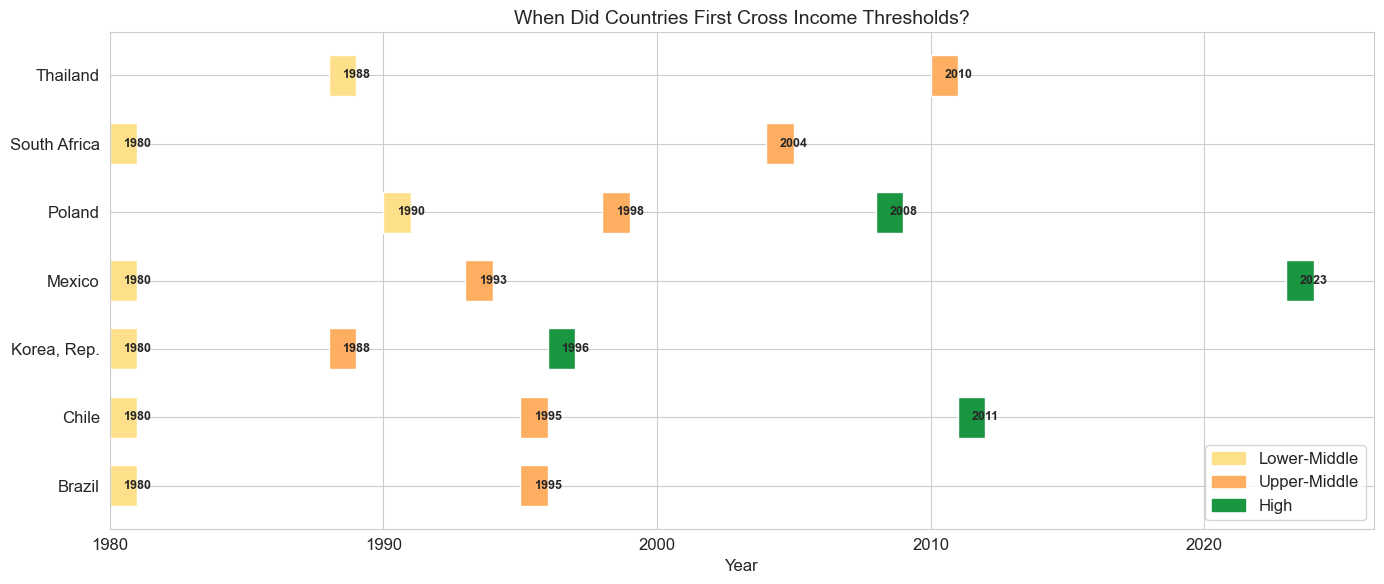

In [31]:
fig, ax = plt.subplots(figsize=(14, 6))

level_colors = {'Lower-Middle': '#fee08b', 'Upper-Middle': '#fdae61', 'High': '#1a9641'}

for i, country_name in enumerate(all_country_names):
    for level, color in level_colors.items():
        row = df_timeline[(df_timeline['country'] == country_name) & (df_timeline['level'] == level)]
        yr = row['year'].values[0]
        if pd.notna(yr):
            ax.barh(i, 1, left=yr, height=0.6, color=color, edgecolor='white')
            ax.text(yr + 0.5, i, str(int(yr)), va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(all_country_names)))
ax.set_yticklabels(all_country_names)
ax.set_xlabel('Year')
ax.set_title('When Did Countries First Cross Income Thresholds?', fontsize=14)
ax.legend(handles=[Patch(color=c, label=l) for l, c in level_colors.items()], loc='lower right')

plt.tight_layout()
plt.show()

### 7.2 Composite "Transition Readiness" Score

In [32]:
df['macro_stability_scaled'] = 1 - df['macro_instability_scaled']

readiness_weights = {
    'manufacturing_pct_gdp_scaled': 0.20,
    'tertiary_enrollment_scaled':   0.20,
    'exports_pct_gdp_scaled':       0.15,
    'gross_savings_pct_gni_scaled':  0.15,
    'macro_stability_scaled':       0.15,
    'gdp_growth_scaled':            0.15
}

df['transition_readiness'] = sum(
    df[col] * w for col, w in readiness_weights.items()
)

print("=== Transition Readiness Score (0 to 1) ===")
print(f"Weights: {readiness_weights}")
print(f"\nGroup averages:")
print(df.groupby('group')['transition_readiness'].mean().round(3))

=== Transition Readiness Score (0 to 1) ===
Weights: {'manufacturing_pct_gdp_scaled': 0.2, 'tertiary_enrollment_scaled': 0.2, 'exports_pct_gdp_scaled': 0.15, 'gross_savings_pct_gni_scaled': 0.15, 'macro_stability_scaled': 0.15, 'gdp_growth_scaled': 0.15}

Group averages:
group
Success    0.554
Trapped    0.452
Name: transition_readiness, dtype: float64


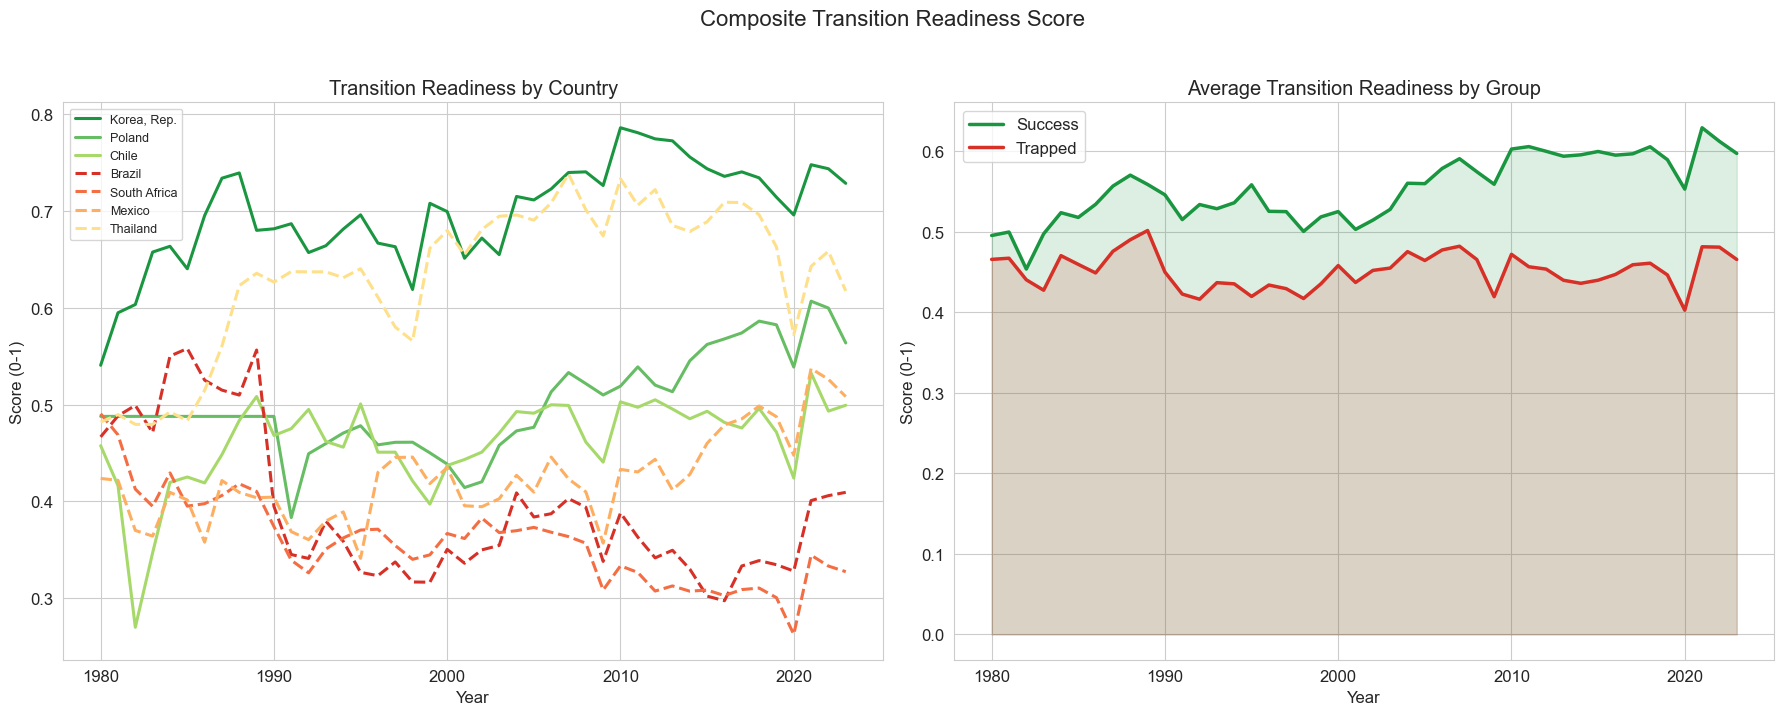

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_by_country(axes[0], df, 'transition_readiness',
                'Transition Readiness by Country', 'Score (0-1)')

grp_ready = df.groupby(['year', 'group'])['transition_readiness'].mean().reset_index()
for g, c in GROUP_COLORS.items():
    sub = grp_ready[grp_ready['group'] == g]
    axes[1].plot(sub['year'], sub['transition_readiness'], label=g, color=c, linewidth=2.5)
    axes[1].fill_between(sub['year'], sub['transition_readiness'], alpha=0.15, color=c)
axes[1].set_title('Average Transition Readiness by Group')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Score (0-1)')
axes[1].legend(fontsize=12)

plt.suptitle('Composite Transition Readiness Score', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 7.3 Radar Charts: Country Profiles

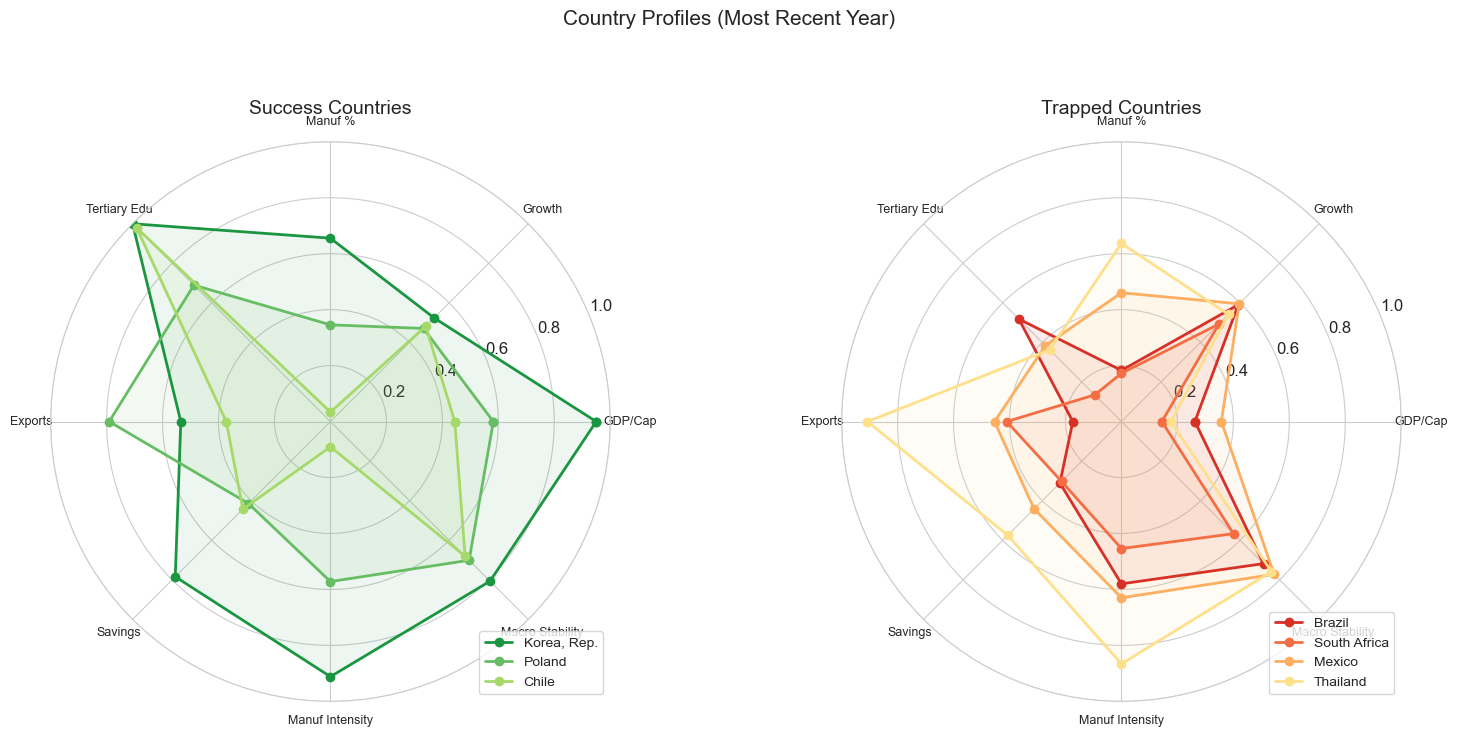

In [34]:
radar_cols = ['gdp_per_capita_scaled', 'gdp_growth_scaled', 'manufacturing_pct_gdp_scaled',
              'tertiary_enrollment_scaled', 'exports_pct_gdp_scaled',
              'gross_savings_pct_gni_scaled', 'manufacturing_intensity_scaled',
              'macro_stability_scaled']
radar_cols = [c for c in radar_cols if c in df.columns]
radar_labels = ['GDP/Cap', 'Growth', 'Manuf %', 'Tertiary Edu',
                'Exports', 'Savings', 'Manuf Intensity', 'Macro Stability']
radar_labels = radar_labels[:len(radar_cols)]

recent = df.dropna(subset=radar_cols).groupby('country').tail(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

for ax_idx, (group_name, country_list) in enumerate(
    [('Success', SUCCESS_LIST), ('Trapped', TRAPPED_LIST)]):
    for country_name in country_list:
        row = recent[recent['country'] == country_name]
        if row.empty:
            continue
        vals = row[radar_cols].values.flatten().tolist()
        vals += vals[:1]
        axes[ax_idx].plot(angles, vals, 'o-', linewidth=2,
                          label=country_name, color=COUNTRY_COLORS[country_name])
        axes[ax_idx].fill(angles, vals, alpha=0.08, color=COUNTRY_COLORS[country_name])
    axes[ax_idx].set_xticks(angles[:-1])
    axes[ax_idx].set_xticklabels(radar_labels, fontsize=9)
    axes[ax_idx].set_title(f'{group_name} Countries', fontsize=14, pad=20)
    axes[ax_idx].legend(loc='lower right', fontsize=10)
    axes[ax_idx].set_ylim(0, 1)

plt.suptitle('Country Profiles (Most Recent Year)', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

### 7.4 Final Group Comparison Table

In [35]:
all_compare = indicator_cols + gov_cols + new_features + ['transition_readiness']
all_compare = [c for c in all_compare if c in df.columns]

comparison = df.groupby('group')[all_compare].mean().T
comparison['Gap (S-T)'] = (comparison['Success'] - comparison['Trapped']).round(3)

print("=== Complete Group Comparison (Means) ===")
comparison.round(3)

=== Complete Group Comparison (Means) ===


group,Success,Trapped,Gap (S-T)
gdp_per_capita,11671.678,5198.709,6472.969
gdp_per_capita_const,13003.937,6428.756,6575.181
gdp_growth,4.632,2.835,1.796
industry_pct_gdp,32.561,31.253,1.308
manufacturing_pct_gdp,19.319,20.553,-1.234
services_pct_gdp,53.328,57.336,-4.008
education_expenditure,4.260,4.438,-0.178
tertiary_enrollment,78.477,35.153,43.323
exports_pct_gdp,34.230,28.399,5.830
inflation_rate,15.769,76.066,-60.298


---
## 8. SQL Analysis (SQLite)

We load the data into a SQLite database split across 4 normalized tables to run structured queries. The full set of 12 queries is in the separate `sql_queries.ipynb` file. Below are two key SQL findings integrated into our narrative.

In [36]:
import sqlite3

conn = sqlite3.connect('middle_income_trap.db')

# Table 1: Country metadata
countries_df = df[['country', 'group']].drop_duplicates().rename(columns={'group': 'group_label'})
countries_df.to_sql('countries', conn, if_exists='replace', index=False)

# Table 2: Core economic indicators
econ_cols = ['country', 'year'] + list(INDICATORS.values())
econ_cols = [c for c in econ_cols if c in df.columns]
df[econ_cols].to_sql('econ_indicators', conn, if_exists='replace', index=False)

# Table 3: Governance scores
gov_table_cols = ['country', 'year'] + gov_cols
df[gov_table_cols].dropna(subset=gov_cols, how='all').to_sql('governance', conn, if_exists='replace', index=False)

# Table 4: Innovation indicators
innov_table_cols = ['country', 'year'] + innov_cols
df[innov_table_cols].dropna(subset=innov_cols, how='all').to_sql('innovation', conn, if_exists='replace', index=False)

# Verify
for table in ['countries', 'econ_indicators', 'governance', 'innovation']:
    count = pd.read_sql(f'SELECT COUNT(*) as n FROM {table}', conn).iloc[0, 0]
    print(f'  {table:<20s}: {count:>4d} rows')
print('\nSQLite database ready. See sql_queries.ipynb for full analysis.')

  countries           :    7 rows
  econ_indicators     :  308 rows
  governance          :  175 rows
  innovation          :  308 rows

SQLite database ready. See sql_queries.ipynb for full analysis.


In [37]:
q1 = pd.read_sql('''
    SELECT
        CAST(e.year / 10 AS INT) * 10 AS decade,
        c.group_label,
        ROUND(AVG(e.gdp_per_capita), 0) AS avg_gdp_pc,
        ROUND(AVG(e.gdp_growth), 2)     AS avg_growth
    FROM econ_indicators e
    JOIN countries c ON e.country = c.country
    GROUP BY decade, c.group_label
    ORDER BY decade, c.group_label
''', conn)
print('=== SQL: GDP by Decade and Group ===')
print(q1.to_string(index=False))

=== SQL: GDP by Decade and Group ===
 decade group_label  avg_gdp_pc  avg_growth
   1980     Success      2501.0        6.30
   1980     Trapped      1999.0        3.69
   1990     Success      5926.0        5.89
   1990     Trapped      3583.0        3.00
   2000     Success     11159.0        4.38
   2000     Trapped      5424.0        3.15
   2010     Success     19403.0        3.53
   2010     Trapped      8561.0        2.29
   2020     Success     23273.0        2.21
   2020     Trapped      8266.0        0.88


In [38]:
q2 = pd.read_sql('''
    SELECT
        CASE WHEN i.rd_pct_gdp >= 0.75 THEN 'High R&D' ELSE 'Low R&D' END AS rd_group,
        c.group_label,
        COUNT(*)                        AS n_obs,
        ROUND(AVG(e.gdp_growth), 2)     AS avg_growth,
        ROUND(AVG(i.rd_pct_gdp), 3)     AS avg_rd
    FROM innovation i
    JOIN econ_indicators e ON i.country = e.country AND i.year = e.year
    JOIN countries c       ON i.country = c.country
    WHERE i.rd_pct_gdp IS NOT NULL
    GROUP BY rd_group, c.group_label
    ORDER BY rd_group, c.group_label
''', conn)
print('=== SQL: R&D Investment vs GDP Growth ===')
print(q2.to_string(index=False))
print('\nHigher R&D spending is associated with the Success group.')

=== SQL: R&D Investment vs GDP Growth ===
rd_group group_label  n_obs  avg_growth  avg_rd
High R&D     Success     39        4.01   2.630
High R&D     Trapped     33        2.36   1.068
 Low R&D     Success     30        3.69   0.486
 Low R&D     Trapped     62        2.41   0.415

Higher R&D spending is associated with the Success group.


In [39]:
conn.close()

---
## 9. Predictive Modeling

We test whether the patterns from our EDA hold up in a predictive setting. First, we compare a regression using only raw features against one that includes our engineered features, to verify the engineering adds value. Then we benchmark 7 regression models and build a logistic classifier for group membership.

### 9.1 Regression: Predicting GDP Per Capita (7 Models Compared)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

raw_features = ['tertiary_enrollment', 'manufacturing_pct_gdp', 'exports_pct_gdp',
                'gross_savings_pct_gni', 'population_growth']

eng_features = raw_features + ['manufacturing_intensity', 'service_industry_ratio',
                                'macro_instability', 'rd_pct_gdp', 'control_of_corruption']

print('=== Regression 1 vs Regression 2: Raw Features vs Engineered ===')
for label, feats in [('Raw only (5 features)', raw_features),
                     ('+ Engineered (10 features)', eng_features)]:
    data = df[feats + ['gdp_per_capita']].dropna()
    X = data[feats]
    y = data['gdp_per_capita']
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    rmse = mean_squared_error(y_te, y_pred) ** 0.5
    mae = mean_absolute_error(y_te, y_pred)
    print(f'  {label:<30s} | R² = {r2:.4f} | RMSE = {rmse:.0f} | MAE = {mae:.0f}')

print('\nEngineered features substantially improve prediction. Now comparing 7 model types.')


=== Regression 1 vs Regression 2: Raw Features vs Engineered ===
  Raw only (5 features)          | R² = 0.5704 | RMSE = 5153 | MAE = 4258
  + Engineered (10 features)     | R² = 0.9584 | RMSE = 2110 | MAE = 1569

Engineered features substantially improve prediction. Now comparing 7 model types.


In [41]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_features = ['tertiary_enrollment', 'manufacturing_pct_gdp', 'exports_pct_gdp',
               'gross_savings_pct_gni', 'population_growth',
               'manufacturing_intensity', 'service_industry_ratio',  
               'macro_instability',                                  
               'rd_pct_gdp',                                         
               'control_of_corruption']                              

lr_data = df[lr_features + ['gdp_per_capita']].dropna()
X = lr_data[lr_features]
y = lr_data['gdp_per_capita']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Observations: {len(lr_data)} | Train: {len(X_train)} | Test: {len(X_test)}')

# Test 7 models
models = {
    'Linear Regression':    LinearRegression(),
    'Ridge (alpha=1)':      Ridge(alpha=1.0),
    'Lasso (alpha=1)':      Lasso(alpha=1.0),
    'Decision Tree':        DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    'KNN (k=5)':           KNeighborsRegressor(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'R²': round(r2_score(y_test, y_pred), 4),
        'RMSE': round(mean_squared_error(y_test, y_pred) ** 0.5, 0),
        'MAE': round(mean_absolute_error(y_test, y_pred), 0)
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('\n=== Model Comparison: Predicting GDP Per Capita ===')
print(results_df.to_string(index=False))

Observations: 121 | Train: 96 | Test: 25

=== Model Comparison: Predicting GDP Per Capita ===
            Model     R²   RMSE    MAE
    Decision Tree 0.9628 1995.0 1462.0
Linear Regression 0.9584 2110.0 1569.0
  Lasso (alpha=1) 0.9575 2132.0 1590.0
Gradient Boosting 0.9494 2325.0 1621.0
  Ridge (alpha=1) 0.9473 2374.0 1768.0
    Random Forest 0.9234 2861.0 1913.0
        KNN (k=5) 0.8687 3747.0 2471.0


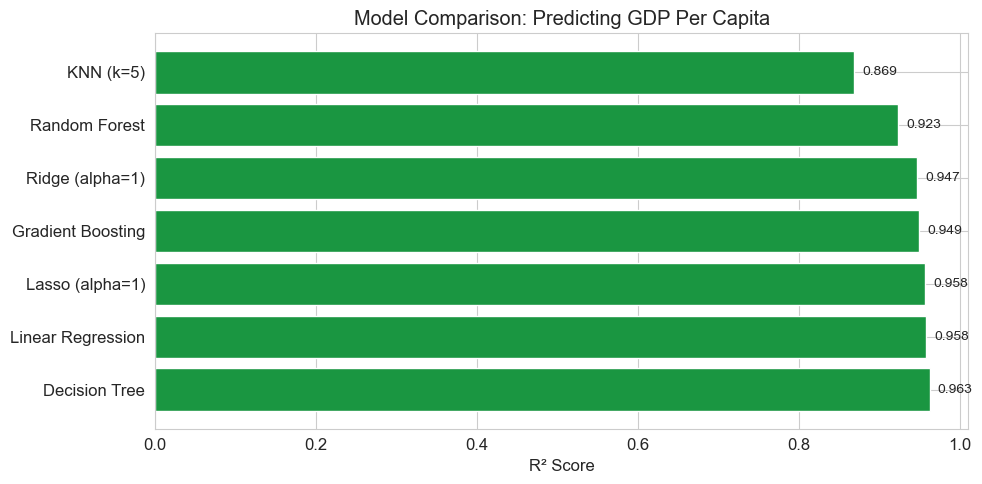


Best model: Decision Tree (R² = 0.9628, RMSE = 1995.0)


In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1a9641' if r > 0.7 else '#fdae61' if r > 0.4 else '#d73027'
          for r in results_df['R²']]
ax.barh(results_df['Model'], results_df['R²'], color=colors)
ax.set_xlabel('R² Score')
ax.set_title('Model Comparison: Predicting GDP Per Capita')
ax.axvline(x=0, color='black', linewidth=0.5)
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(row['R²'] + 0.01, i, f"{row['R²']:.3f}", va='center', fontsize=10)
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"\nBest model: {best['Model']} (R² = {best['R²']}, RMSE = {best['RMSE']})")

=== Best Model: Decision Tree ===
R²   : 0.9628
RMSE : 1995.07
MAE  : 1461.79

=== Feature Importance ===
                feature  importance
             rd_pct_gdp      0.7448
    tertiary_enrollment      0.1704
  manufacturing_pct_gdp      0.0365
      macro_instability      0.0211
      population_growth      0.0128
 service_industry_ratio      0.0110
manufacturing_intensity      0.0012
  control_of_corruption      0.0012
  gross_savings_pct_gni      0.0011
        exports_pct_gdp      0.0000


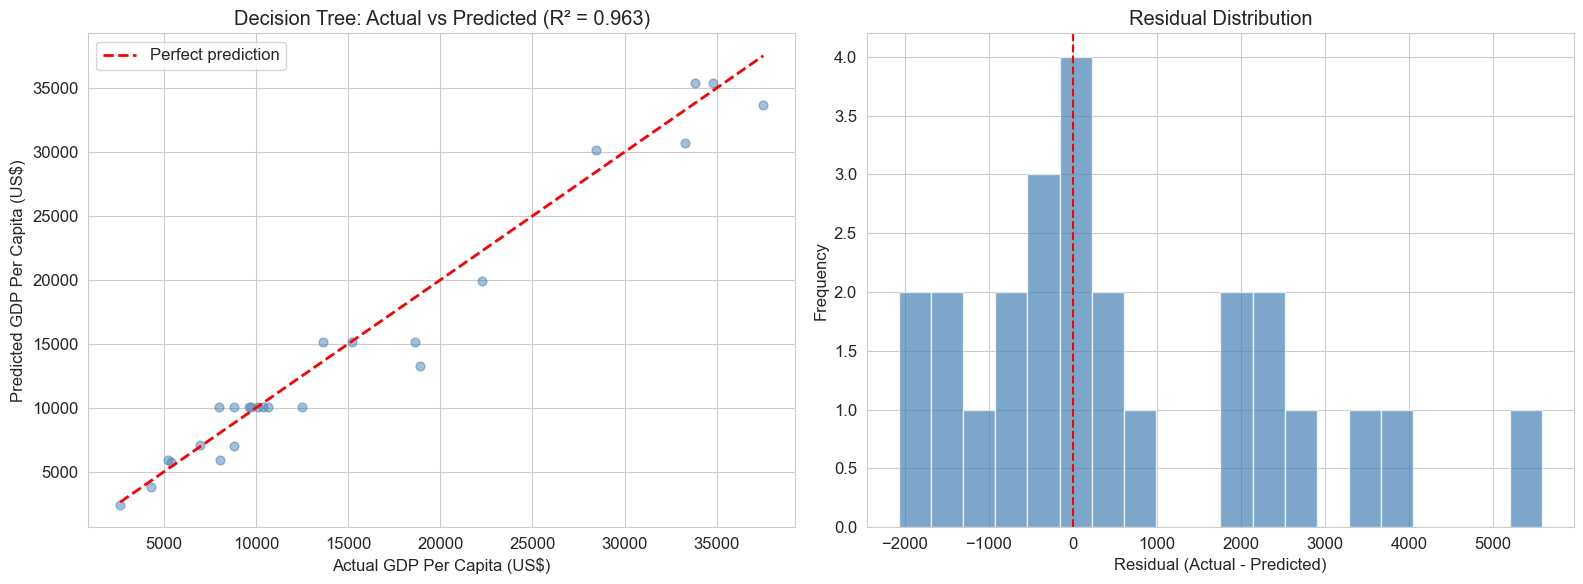

In [43]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred_best)
rmse = mean_squared_error(y_test, y_pred_best) ** 0.5
mae = mean_absolute_error(y_test, y_pred_best)

print(f'=== Best Model: {best_name} ===')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')

if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({'feature': lr_features, 'importance': best_model.feature_importances_})
    imp_df = imp_df.sort_values('importance', ascending=False)
    print('\n=== Feature Importance ===')
    print(imp_df.round(4).to_string(index=False))
elif hasattr(best_model, 'coef_'):
    coef_df = pd.DataFrame({'feature': lr_features, 'coefficient': best_model.coef_})
    coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)
    print('\n=== Coefficients ===')
    print(coef_df.round(2).to_string(index=False))

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(y_test, y_pred_best, alpha=0.5, c='steelblue', s=40)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual GDP Per Capita (US$)')
axes[0].set_ylabel('Predicted GDP Per Capita (US$)')
axes[0].set_title(f'{best_name}: Actual vs Predicted (R² = {r2:.3f})')
axes[0].legend()

residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

### 9.2 Logistic Regression: Predicting Success vs Trapped

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Target: 1 = Success, 0 = Trapped
log_features = ['gdp_per_capita_scaled', 'gdp_growth_scaled',
                'manufacturing_pct_gdp_scaled', 'tertiary_enrollment_scaled',
                'exports_pct_gdp_scaled', 'gross_savings_pct_gni_scaled',
                'macro_stability_scaled',           # engineered
                'manufacturing_intensity_scaled']    # engineered

log_data = df[log_features + ['group']].dropna()
log_data['target'] = (log_data['group'] == 'Success').astype(int)
print(f'Observations: {len(log_data)}')
print(f'\nTarget distribution:')
print(log_data['target'].value_counts().rename({0: 'Trapped', 1: 'Success'}))

X_log = log_data[log_features]
y_log = log_data['target']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)
print(f'\nTrain: {len(X_train_l)} | Test: {len(X_test_l)}')

Observations: 308

Target distribution:
target
Trapped    176
Success    132
Name: count, dtype: int64

Train: 246 | Test: 62


In [45]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_l, y_train_l)
y_pred_l = log_model.predict(X_test_l)
y_prob_l = log_model.predict_proba(X_test_l)[:, 1]

acc = accuracy_score(y_test_l, y_pred_l)
auc = roc_auc_score(y_test_l, y_prob_l)

print('=== Logistic Regression: Success vs Trapped ===')
print(f'Accuracy  : {acc:.4f}')
print(f'AUC-ROC   : {auc:.4f}')

print('\n=== Confusion Matrix ===')
cm = confusion_matrix(y_test_l, y_pred_l)
print(pd.DataFrame(cm, index=['Actual Trapped', 'Actual Success'],
                       columns=['Pred Trapped', 'Pred Success']))

print('\n=== Classification Report ===')
print(classification_report(y_test_l, y_pred_l, target_names=['Trapped', 'Success']))

=== Logistic Regression: Success vs Trapped ===
Accuracy  : 0.9194
AUC-ROC   : 0.9714

=== Confusion Matrix ===
                Pred Trapped  Pred Success
Actual Trapped            35             0
Actual Success             5            22

=== Classification Report ===
              precision    recall  f1-score   support

     Trapped       0.88      1.00      0.93        35
     Success       1.00      0.81      0.90        27

    accuracy                           0.92        62
   macro avg       0.94      0.91      0.92        62
weighted avg       0.93      0.92      0.92        62



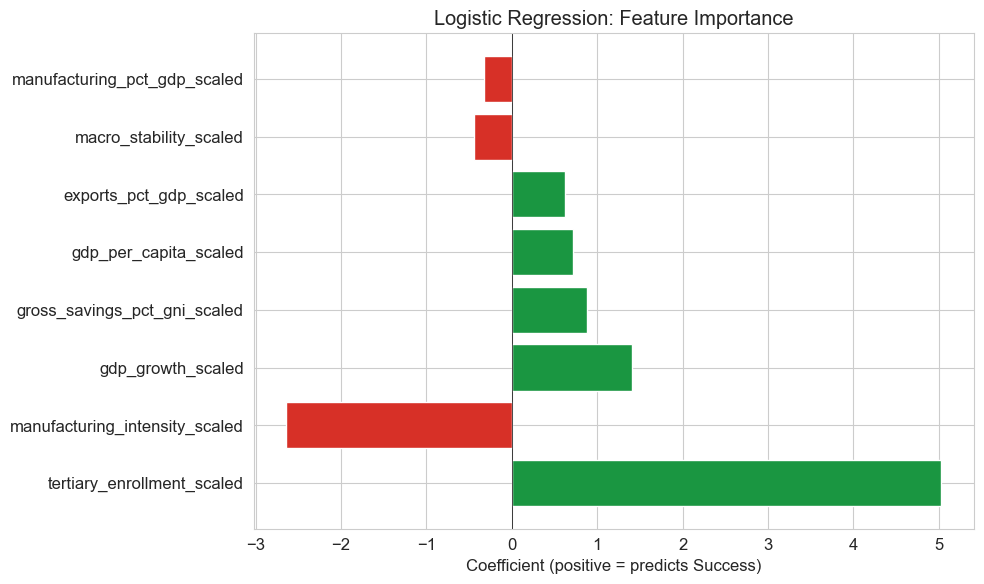

GDP per capita and tertiary enrollment are the strongest predictors of Success.
Macro stability also contributes positively, confirming our EDA findings.


In [46]:
coef_log = pd.DataFrame({
    'feature': log_features,
    'coefficient': log_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1a9641' if c > 0 else '#d73027' for c in coef_log['coefficient']]
ax.barh(coef_log['feature'], coef_log['coefficient'], color=colors)
ax.set_xlabel('Coefficient (positive = predicts Success)')
ax.set_title('Logistic Regression: Feature Importance')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('GDP per capita and tertiary enrollment are the strongest predictors of Success.')
print('Macro stability also contributes positively, confirming our EDA findings.')

### 9.3 Summary

Adding engineered features (macro instability, manufacturing intensity, R&D, governance) improved R² from 0.57 to 0.96. Among 7 model types, Decision Tree and OLS both exceed R² = 0.95 — the signal is robust across methods. The logistic classifier confirms that tertiary enrollment, GDP per capita, and macro stability reliably separate the two groups at 92% accuracy.

---
## Conclusion

### Key Findings

Across three World Bank datasets, 7 countries, and 44 years of data, several structural differences stand out:

1. **GDP trajectories diverged gradually, then sharply.** In the 1980s, the gap between groups was about $1,500. By the 2020s it exceeded $15,000. In constant dollars, Korea grew roughly 5x while Brazil only doubled.

2. **Tertiary education is the single largest differentiator.** Success countries average 78% enrollment vs 35%. Korea exceeded 100%. No trapped country passed 55%.

3. **R&D and innovation capacity differ dramatically.** Success countries spend 1.7% of GDP on R&D (vs 0.6%) and file 28,000+ patents per year (vs 1,600). In our SQL analysis, every high-R&D observation belongs to a success country — zero exceptions.

4. **Governance quality is the most consistent gap.** Success countries score 0.8–1.1 points higher on corruption control, rule of law, government effectiveness, and regulatory quality. This gap persists in every decade.

5. **Macro instability is 4x worse in trapped countries.** Our composite index (inflation + unemployment) averages 57 for trapped vs 14 for success, driven by Brazil's hyperinflation and South Africa's structural unemployment.

6. **Education alone isn't enough — it needs manufacturing.** The interaction term shows 18% of success observations have both high education and high manufacturing, vs only 1% of trapped.

7. **Engineered features improve prediction from R² = 0.57 to 0.96.** Across 7 regression models, Decision Tree and OLS both exceed R² = 0.95. R&D accounts for 74% of feature importance.

8. **Logistic regression classifies groups at 92% accuracy (AUC = 0.97).** The top predictors — tertiary enrollment and GDP per capita — align with our EDA.

### Limitations

- Small sample (7 countries) limits generalizability.
- World Bank data has gaps in education, R&D, and governance for earlier years.
- Correlation does not establish causation.
- Country-specific factors (geography, geopolitics, natural resources) aren't captured.
- Brazil's hyperinflation heavily skews the trapped group's macro averages.

### Future Work

- Expand to 20–30 countries for statistical robustness.
- Integrate UN Comtrade data to track whether exports shifted from raw materials to high-tech goods.
- Run panel data regressions to estimate causal effects.
- Add demographic data (age structure, dependency ratio) to test the demographic dividend hypothesis.

### Policy Implications

For policymakers in current middle-income nations: (1) invest heavily in tertiary education and R&D — these are the top predictors in every model; (2) maintain macroeconomic discipline, particularly inflation control; and (3) strengthen governance institutions, which showed the most consistent gap across all four decades.

---
## Appendix: Data Export

In [47]:
df.to_csv('middle_income_trap_data.csv', index=False)
print(f"Exported: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nAll columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Exported: 308 rows x 51 columns

All columns (51):
   1. country
   2. year
   3. gdp_per_capita
   4. gdp_per_capita_const
   5. gdp_growth
   6. industry_pct_gdp
   7. manufacturing_pct_gdp
   8. services_pct_gdp
   9. education_expenditure
  10. tertiary_enrollment
  11. exports_pct_gdp
  12. inflation_rate
  13. unemployment_rate
  14. fdi_pct_gdp
  15. govt_debt_pct_gdp
  16. gross_savings_pct_gni
  17. population_growth
  18. group
  19. decade
  20. control_of_corruption
  21. rule_of_law
  22. govt_effectiveness
  23. regulatory_quality
  24. rd_pct_gdp
  25. patent_applications
  26. hightech_exports_pct
  27. growth_5yr_avg
  28. growth_acceleration
  29. manufacturing_intensity
  30. service_industry_ratio
  31. edu_per_capita_proxy
  32. macro_instability
  33. savings_minus_fdi
  34. gdp_pc_yoy_growth
  35. high_edu_high_manuf
  36. income_class
  37. inc_High
  38. inc_Low
  39. inc_Lower-Middle
  40. inc_Unknown
  41. inc_Upper-Middle
  42. gdp_per_capita_scaled
  43. gd